# Titulo
- Fuente de datos:
- Intro:

## Analisis objetivo
  - Laptops mas caras del mercado, que valores afectan en su precio
  - Laptops nmas baratas, que afectan a su precio
  - Empresas mas relevantes y empresas no tan relevantes
## Glosario

# Librerias
- Pandas
- Matplotlib

In [152]:
import seaborn as sns
import plotly.graph_objects as go

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


# 1. Comprencion de datos
  - Carga de datos
  - Filtrado de comlumnas interesantes
  - Descripcion de datos 

In [153]:
df = pd.read_csv("laptop-price.csv")

#Mostrar el precio en Dolare USD
tasa_cambio = 0.0118025
df["Price"] = df["Price"] * tasa_cambio
df.to_csv("Price", index=False)

#Borrar columnas irrelevantes
df.drop(columns=["index"], inplace=True)
df.drop(columns="Weight", inplace=True)
#Dataframe
df

,Company,TypeName,Ram,Price,Touchscreen,Ips,ppi,Cpu brand,HDD,SSD,Hybrid,Flash_Storage,Gpu brand,os
0,Apple,Ultrabook,8,842.446908,0,1,226.983005,Intel Core i5,0,128,0,0,Intel,Mac
1,Apple,Ultrabook,8,565.286913,0,0,127.677940,Intel Core i5,0,0,0,128,Intel,Mac
2,HP,Notebook,8,361.581390,0,0,141.211998,Intel Core i5,0,256,0,0,Intel,Others/No OS/Linux
3,Apple,Ultrabook,16,1595.642953,0,1,220.534624,Intel Core i7,0,512,0,0,AMD,Mac
4,Apple,Ultrabook,8,1134.170774,0,1,226.983005,Intel Core i5,0,256,0,0,Intel,Mac
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1263,Lenovo,2 in 1 Convertible,4,401.198134,1,1,157.350512,Intel Core i7,0,128,0,0,Intel,Windows
1264,Lenovo,2 in 1 Convertible,16,942.626963,1,1,276.053530,Intel Core i7,0,512,0,0,Intel,Windows
1265,Lenovo,Notebook,2,144.003719,0,0,111.935204,Other Intel Processor,0,0,0,64,Intel,Windows
1266,HP,Notebook,6,480.431621,0,0,100.454670,Intel Core i7,1000,0,0,0,AMD,Windows


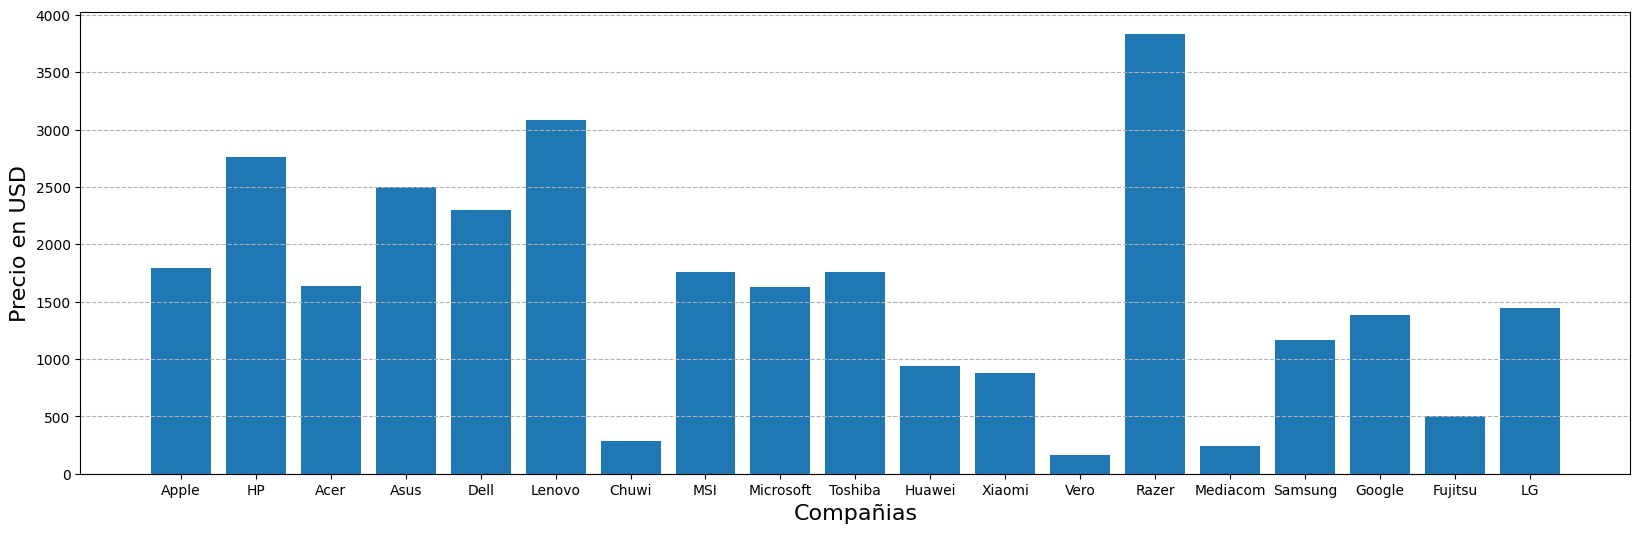

In [154]:
#Grafico del precio MATPLOTLIB
Precio = df["Price"]
Compañia = df["Company"]

fig, ax = plt.subplots(
    figsize = (20,6)
)
ax = plt.bar(Compañia, Precio)
ax = plt.grid(axis="y", linestyle="--")
ax = plt.xlabel("Compañias", fontsize=16)
ax = plt.ylabel("Precio en USD", fontsize=16)


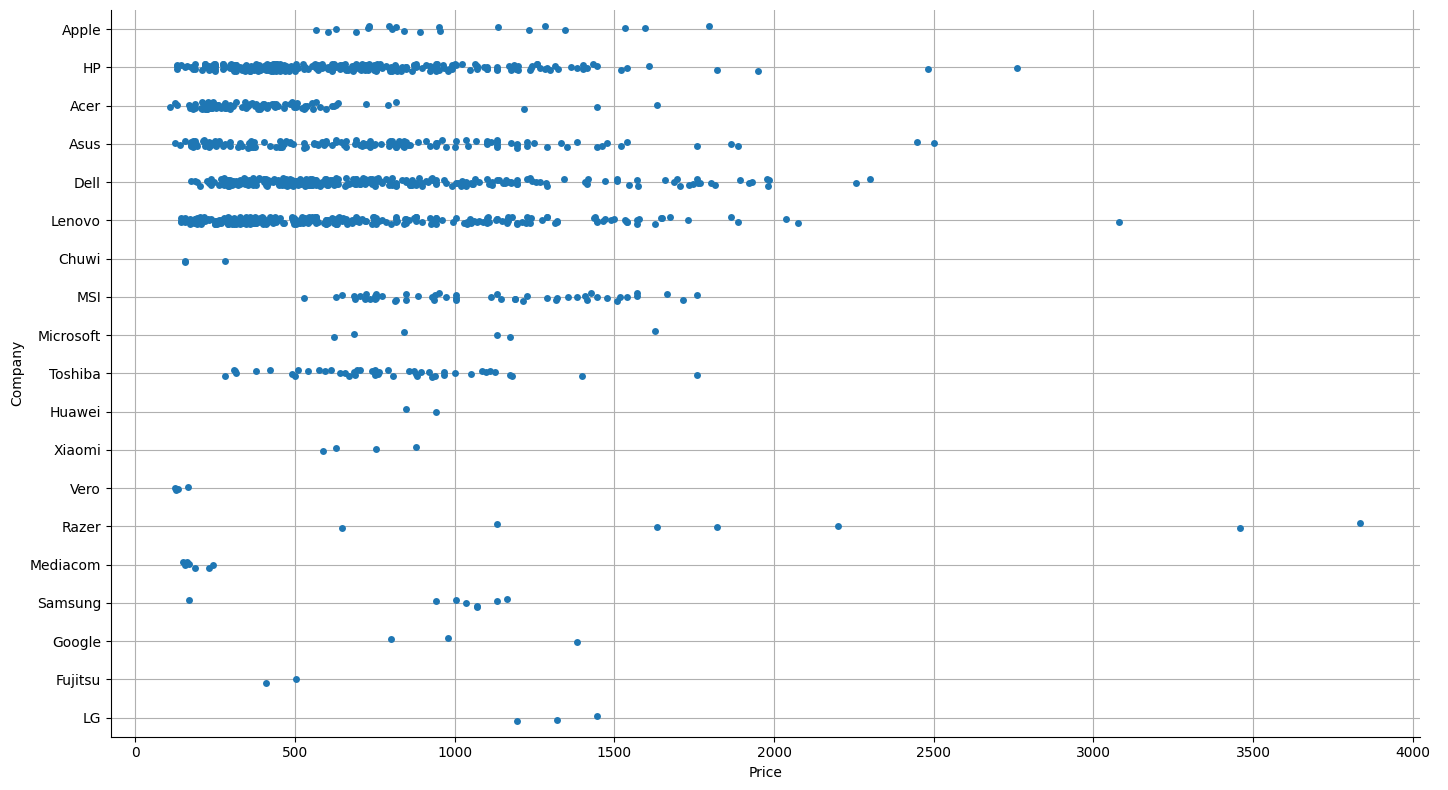

In [155]:
#Grafico de dispersion de la relacion entre la marca de laptop y el precio
Precio = df["Price"]
Compañia = df["Company"]


sns.catplot(df, x=Precio, y=Compañia, height=8, aspect=1.8)
plt.grid(True)


### Contando cantidad de datos por cada variable presente

#### Cantidad de tipos de laptops

Text(0, 0.5, 'GPU')

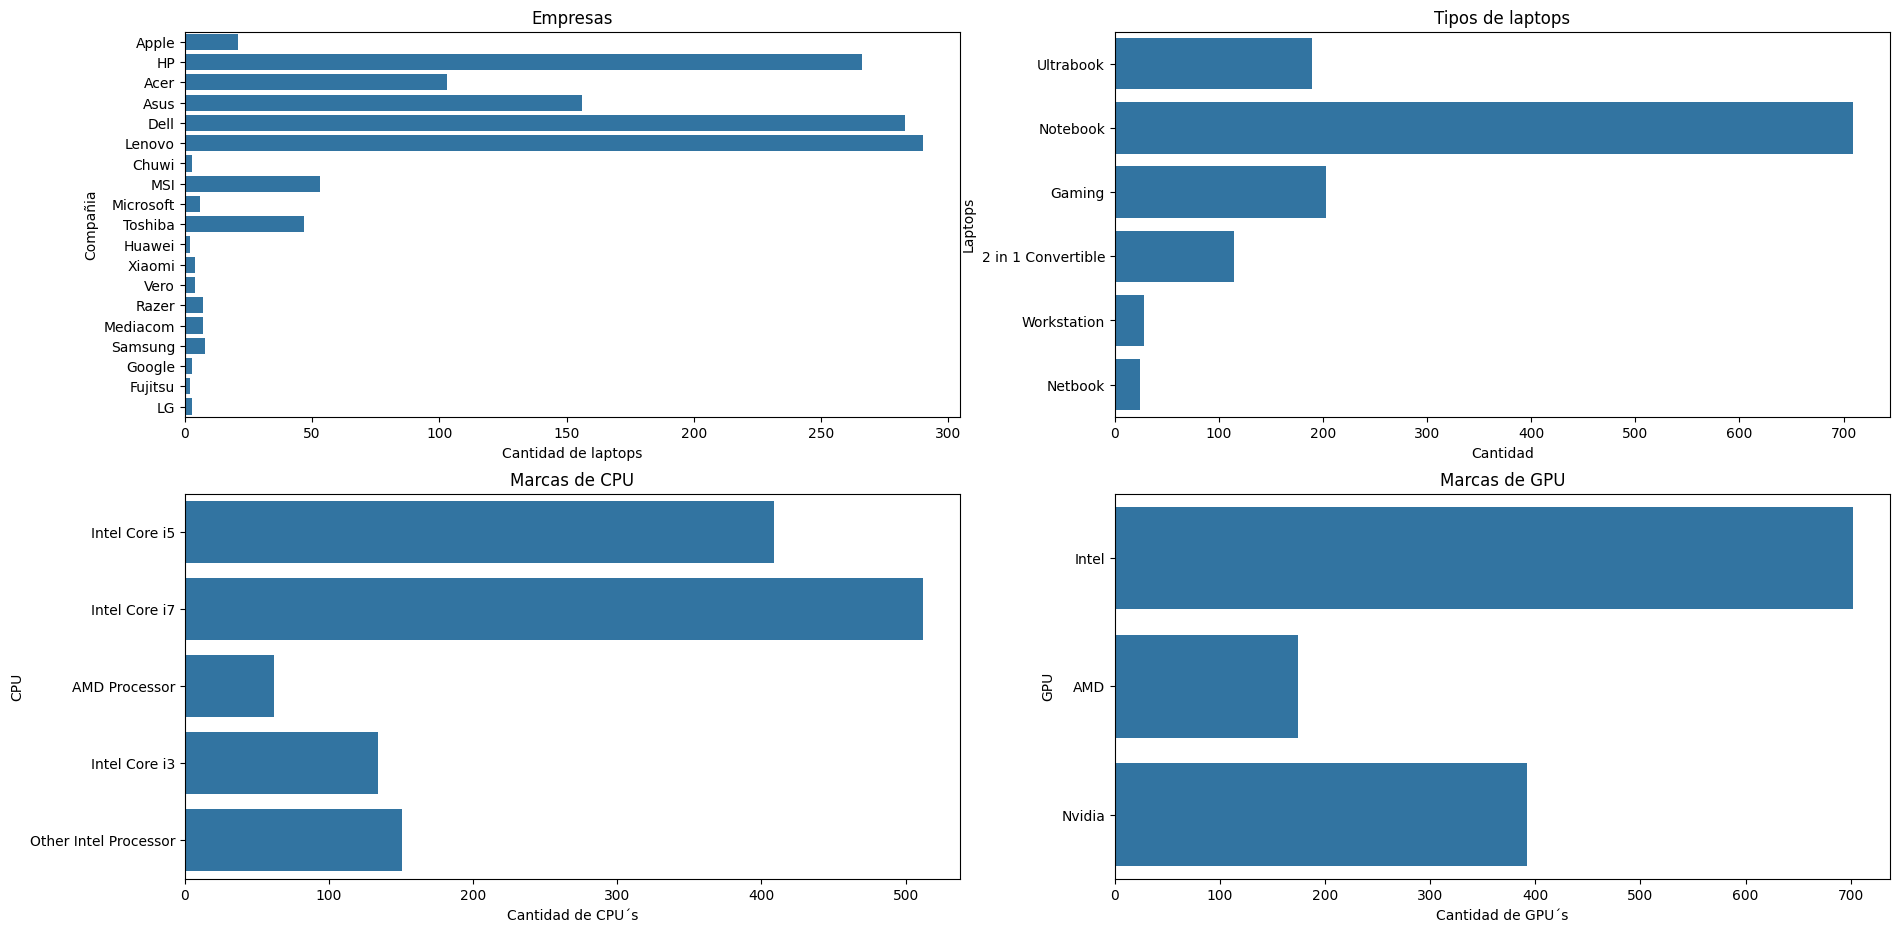

In [156]:
#SEABORN
data_company = df["Company"]
data_typename = df["TypeName"]
data_cpubrand = df["Cpu brand"]
data_gpubrand = df["Gpu brand"]

fig, axs = plt.subplots(
    figsize=(22, 11), nrows=2, ncols=2
)

#grafico; Cantidad de laptops por empresa presentes en el DataSet
sns.countplot(data_company, ax=axs[0,0])
axs[0,0].set_title("Empresas")
axs[0,0].set_xlabel("Cantidad de laptops")
axs[0,0].set_ylabel("Compañia")

#Grafico cantidad de tipos de laptops
sns.countplot(data_typename, ax=axs[0,1])
axs[0,1].set_title("Tipos de laptops")
axs[0,1].set_xlabel("Cantidad")
axs[0,1].set_ylabel("Laptops")

#Grafico cantidad de marcas de Cpu
sns.countplot(data_cpubrand, ax=axs[1,0])
axs[1,0].set_title("Marcas de CPU")
axs[1,0].set_xlabel("Cantidad de CPU´s")
axs[1,0].set_ylabel("CPU")
#Grafico cantidad de marcas de Gpu
sns.countplot(data_gpubrand, ax= axs[1,1])
axs[1,1].set_title("Marcas de GPU")
axs[1,1].set_xlabel("Cantidad de GPU´s")
axs[1,1].set_ylabel("GPU")



## Tipos de valores presentes en las columnas

In [157]:
df.dtypes

Company           object
TypeName          object
Ram                int64
Price            float64
Touchscreen        int64
Ips                int64
ppi              float64
Cpu brand         object
HDD                int64
SSD                int64
Hybrid             int64
Flash_Storage      int64
Gpu brand         object
os                object
dtype: object

## valores presentes en cada columna

In [158]:
#Mostrar las datos de las columnas de las marcas de empresas presentes
df_data_company = set(df["Company"])
df_data_Typename = set(df["TypeName"])
df_data_cpubrand = set(df["Cpu brand"])
df_data_gpubrand = set(df["Gpu brand"])
df_data_ram = set(df["Ram"])
df_data_SSD = set(df["SSD"])

In [159]:
#Compañias que venden las laptops
df_data_company

{'Acer',
 'Apple',
 'Asus',
 'Chuwi',
 'Dell',
 'Fujitsu',
 'Google',
 'HP',
 'Huawei',
 'LG',
 'Lenovo',
 'MSI',
 'Mediacom',
 'Microsoft',
 'Razer',
 'Samsung',
 'Toshiba',
 'Vero',
 'Xiaomi'}

In [160]:
df_data_Typename 

{'2 in 1 Convertible',
 'Gaming',
 'Netbook',
 'Notebook',
 'Ultrabook',
 'Workstation'}

In [161]:
df_data_cpubrand 

{'AMD Processor',
 'Intel Core i3',
 'Intel Core i5',
 'Intel Core i7',
 'Other Intel Processor'}

In [162]:
df_data_gpubrand 

{'AMD', 'Intel', 'Nvidia'}

In [163]:
df_data_ram 

{1, 2, 4, 6, 8, 12, 16, 24, 32, 64}

In [164]:
df_data_SSD

{0, 8, 16, 32, 64, 128, 180, 240, 256, 512, 768, 1000, 1024}

## Tipos de variables; Cuantitativas y Cualitativas

In [165]:
# Identificaion de tipos de vairables

#variables cuantitativas
df_Vcuantitativas = df[["Company","Ram", "Price", "Touchscreen", "Ips", "ppi", "HDD", "SSD", "Flash_Storage"]]

#Variables cualitativas
df_Vcualitativas = df[["Company", "TypeName", "Cpu brand", "Gpu brand", "os"]]

In [166]:
#variables cuantitativas
df_Vcuantitativas.sort_values("Price", ascending=False)

,Company,Ram,Price,Touchscreen,Ips,ppi,HDD,SSD,Flash_Storage
189,Razer,32,3835.278083,1,0,254.671349,0,1000,0
804,Razer,32,3457.975763,1,0,254.671349,0,512,0
594,Lenovo,32,3080.673443,0,1,282.423996,0,1000,0
726,HP,16,2759.966471,0,1,127.335675,0,256,0
1034,Asus,64,2499.627870,0,1,127.335675,0,1000,0
...,...,...,...,...,...,...,...,...,...
765,Vero,4,127.591068,0,0,157.350512,0,0,32
30,Asus,2,125.138603,0,0,111.935204,0,0,32
280,Acer,2,125.138603,0,0,100.454670,0,16,0
1088,Vero,4,123.252091,0,0,165.632118,0,0,32


In [167]:
# Estadisticas descriptivas de las Variables cuantitativas
EST_Descrip = df_Vcuantitativas.describe()


In [168]:
df_Vcualitativas


,Company,TypeName,Cpu brand,Gpu brand,os
0,Apple,Ultrabook,Intel Core i5,Intel,Mac
1,Apple,Ultrabook,Intel Core i5,Intel,Mac
2,HP,Notebook,Intel Core i5,Intel,Others/No OS/Linux
3,Apple,Ultrabook,Intel Core i7,AMD,Mac
4,Apple,Ultrabook,Intel Core i5,Intel,Mac
...,...,...,...,...,...
1263,Lenovo,2 in 1 Convertible,Intel Core i7,Intel,Windows
1264,Lenovo,2 in 1 Convertible,Intel Core i7,Intel,Windows
1265,Lenovo,Notebook,Other Intel Processor,Intel,Windows
1266,HP,Notebook,Intel Core i7,AMD,Windows


## Filtrado de cada compañia por separado

In [169]:
#Cantidad de laptops en cada compañia
df["Company"].value_counts()

Company
Lenovo       290
Dell         283
HP           266
Asus         156
Acer         103
MSI           53
Toshiba       47
Apple         21
Samsung        8
Mediacom       7
Razer          7
Microsoft      6
Vero           4
Xiaomi         4
Chuwi          3
LG             3
Google         3
Huawei         2
Fujitsu        2
Name: count, dtype: int64

In [170]:
df_lenovo = df[(df["Company"] == "Lenovo")]
df_dell = df[(df["Company"] == "Dell")]
df_hp = df[(df["Company"] == "HP")]
df_asus = df[(df["Company"] == "Asus")]
df_acer = df[(df["Company"] == "Acer")]
df_msi = df[(df["Company"] == "MSI")]
df_toshiba = df[(df["Company"] == "Toshiba")]
df_apple = df[(df["Company"] == "Apple")]
df_samsung = df[(df["Company"] == "Samsung")]
df_mediacom = df[(df["Company"] == "Mediacom")]
df_razer = df[(df["Company"] == "Razer")]
df_microsoft = df[(df["Company"] == "Microsoft")]
df_vero = df[(df["Company"] == "Vero")]
df_xiaomi = df[(df["Company"] == "Xiaomi")]
df_chuwi = df[(df["Company"] == "Chuwi")]
df_lg = df[(df["Company"] == "LG")]
df_google = df[(df["Company"] == "Google")]
df_huawei = df[(df["Company"] == "Huawei")]
df_fujitsu = df[(df["Company"] == "Fujitsu")]


### LENOVO

In [171]:
df_lenovo.sort_values("Price", ascending=False)

,Company,TypeName,Ram,Price,Touchscreen,Ips,ppi,Cpu brand,HDD,SSD,Hybrid,Flash_Storage,Gpu brand,os
594,Lenovo,Notebook,32,3080.673443,0,1,282.423996,Other Intel Processor,0,1000,0,0,Nvidia,Windows
722,Lenovo,Workstation,16,2074.533923,0,1,282.423996,Intel Core i7,0,1000,0,0,Nvidia,Windows
1049,Lenovo,Gaming,32,2037.432528,0,1,127.335675,Intel Core i7,0,512,1000,0,Nvidia,Windows
548,Lenovo,Notebook,8,1885.882763,0,1,127.335675,Intel Core i7,0,256,0,0,Nvidia,Windows
986,Lenovo,Notebook,16,1866.388810,0,1,254.671349,Intel Core i7,0,512,0,0,Nvidia,Windows
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34,Lenovo,Notebook,4,156.580463,0,0,111.935204,Other Intel Processor,0,0,0,64,Intel,Windows
618,Lenovo,Notebook,2,156.580463,0,0,111.935204,Other Intel Processor,0,0,0,32,Intel,Windows
1251,Lenovo,Notebook,2,144.003719,0,0,111.935204,Other Intel Processor,0,0,0,64,Intel,Windows
1237,Lenovo,Notebook,2,144.003719,0,0,111.935204,Other Intel Processor,0,0,0,64,Intel,Windows


In [172]:
laptops_types_lenovo = set(df_lenovo["TypeName"])
laptops_types_lenovo

{'2 in 1 Convertible',
 'Gaming',
 'Netbook',
 'Notebook',
 'Ultrabook',
 'Workstation'}

C:\Users\USUARIO\AppData\Local\Temp\ipykernel_29648\4078934130.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[0,0].set_xticklabels(set(df_lenovo["TypeName"]), rotation=10)
C:\Users\USUARIO\AppData\Local\Temp\ipykernel_29648\4078934130.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[0,1].set_xticklabels(set(df_lenovo["TypeName"]), rotation=10)
C:\Users\USUARIO\AppData\Local\Temp\ipykernel_29648\4078934130.py:29: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[1,0].set_xticklabels(set(df_lenovo["Gpu brand"]), rotation=15)
C:\Users\USUARIO\AppData\Local\Temp\ipykernel_29648\4078934130.py:36: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  a

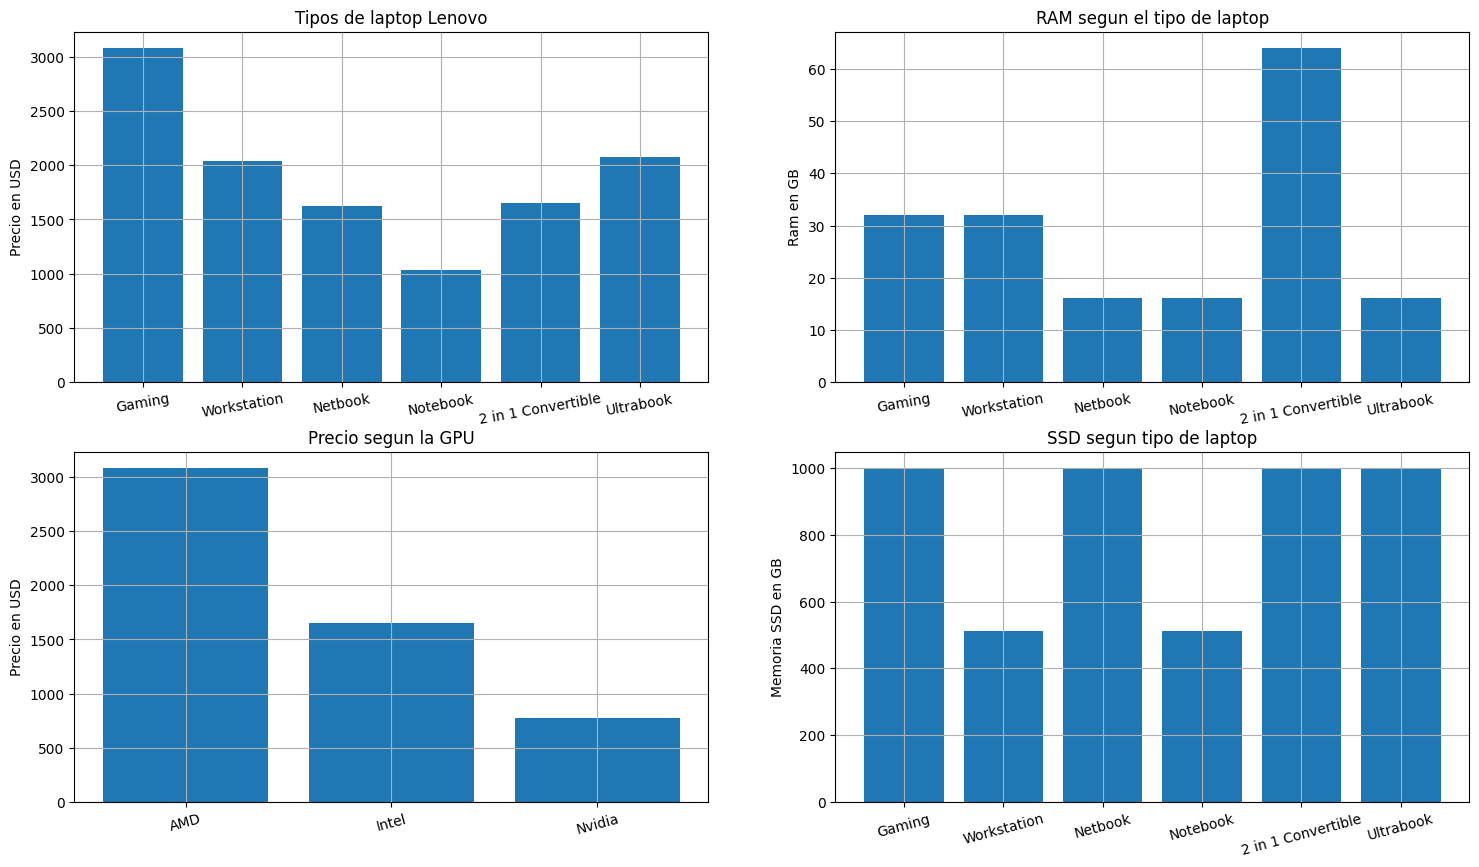

In [173]:
#Usando matplotlib
XTN = df_lenovo["TypeName"]
YP = df_lenovo["Price"]
YRAM = df_lenovo["Ram"]
XGPU = df_lenovo["Gpu brand"]
XMEM = df_lenovo["SSD"]


fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(18, 10))

#Tipo de laptop/Precio
axs[0,0].bar(XTN, YP)
axs[0,0].set_title("Tipos de laptop Lenovo")
axs[0,0].set_xticklabels(set(df_lenovo["TypeName"]), rotation=10)
axs[0,0].set_ylabel("Precio en USD")
axs[0,0].grid(True)

#Tipo de laptop/RAM
axs[0,1].bar(XTN, YRAM)
axs[0,1].set_title("RAM segun el tipo de laptop")
axs[0,1].set_xticklabels(set(df_lenovo["TypeName"]), rotation=10)
axs[0,1].set_ylabel("Ram en GB")
axs[0,1].grid(True)


#Tipo de laptop/Gpu brand
axs[1,0].bar(XGPU, YP)
axs[1,0].set_title("Precio segun la GPU")
axs[1,0].set_xticklabels(set(df_lenovo["Gpu brand"]), rotation=15)
axs[1,0].set_ylabel("Precio en USD")
axs[1,0].grid(True)

#Tipo de memoria/precio
axs[1,1].bar(XTN, XMEM)
axs[1,1].set_title("SSD segun tipo de laptop")
axs[1,1].set_xticklabels(set(df_lenovo["TypeName"]), rotation=15)
axs[1,1].set_ylabel("Memoria SSD en GB")
axs[1,1].grid(True)


C:\Users\USUARIO\AppData\Local\Temp\ipykernel_29648\1750804864.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(df_lenovo, x=XTN_SNS, y=YP_SNS, jitter=True,
C:\Users\USUARIO\AppData\Local\Temp\ipykernel_29648\1750804864.py:11: FutureWarning: Use "auto" to set automatic grayscale colors. From v0.14.0, "gray" will default to matplotlib's definition.
  sns.stripplot(df_lenovo, x=XTN_SNS, y=YP_SNS, jitter=True,


'""\nsns.barplot(XGPU_SNS, ax=axs[1,0])\n'

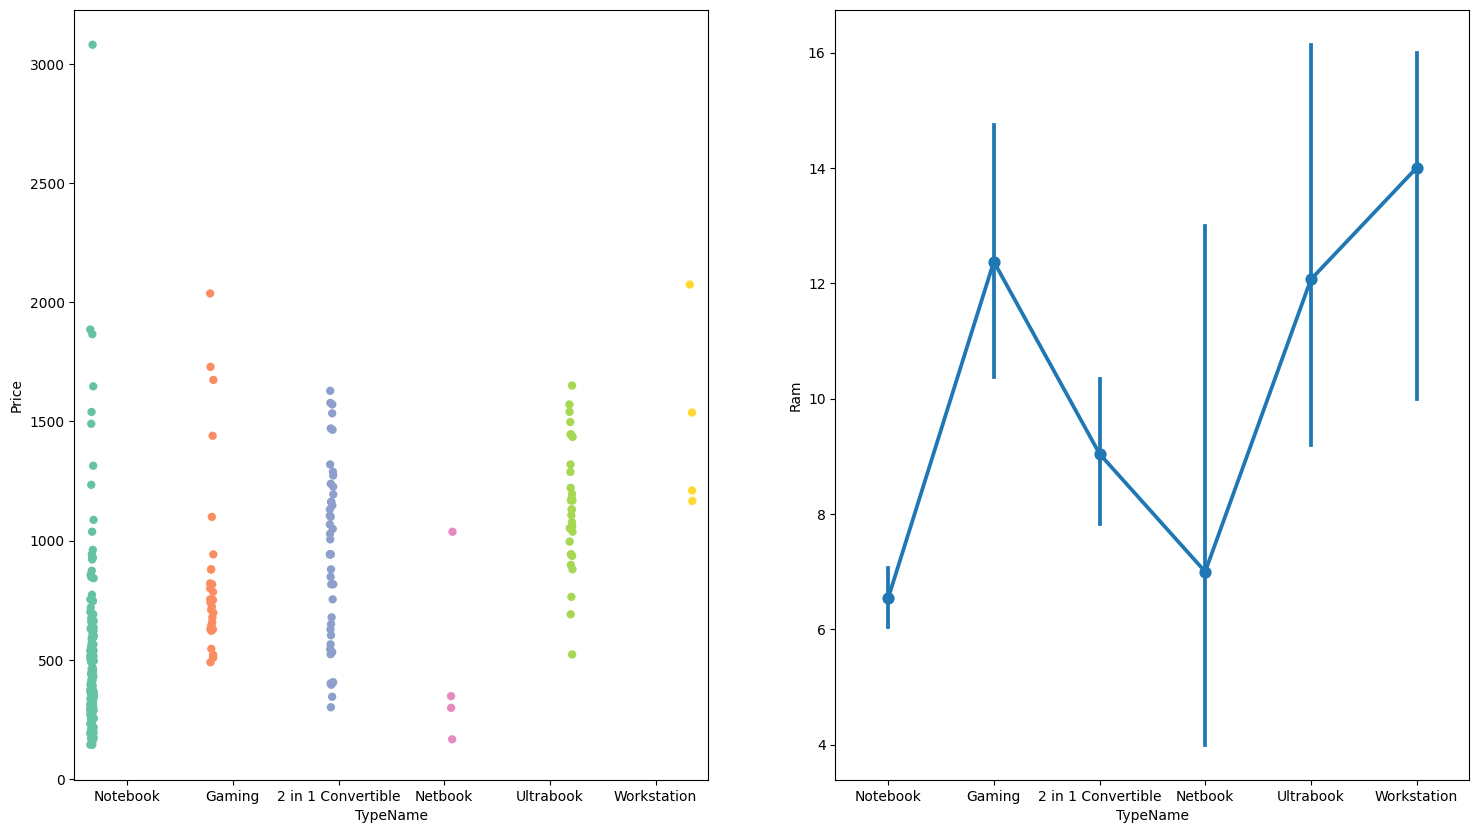

In [274]:
#Usando seaborn
XTN_SNS = df_lenovo["TypeName"]
YP_SNS = df_lenovo["Price"]
YRAM_SNS = df_lenovo["Ram"]
XGPU_SNS = df_lenovo["Gpu brand"]
XMEM_SNS = df_lenovo["SSD"]

fig, axs = plt.subplots(
    ncols=2, figsize=(18,10)
)
sns.stripplot(df_lenovo, x=XTN_SNS, y=YP_SNS, jitter=True,
              dodge=True, palette="Set2", size=6, edgecolor="gray", ax = axs[0])

sns.pointplot(df_lenovo, x=XTN_SNS, y=YRAM_SNS, ax = axs[1])



### DELL

In [175]:
df_dell.sort_values("Price", ascending=False)

,Company,TypeName,Ram,Price,Touchscreen,Ips,ppi,Cpu brand,HDD,SSD,Hybrid,Flash_Storage,Gpu brand,os
702,Dell,Gaming,32,2301.166850,0,0,254.671349,Intel Core i7,1000,1000,0,0,Nvidia,Windows
754,Dell,Gaming,32,2256.770943,0,1,127.335675,Intel Core i7,1000,1000,0,0,Nvidia,Windows
926,Dell,Gaming,16,1983.352529,0,1,254.671349,Intel Core i7,1000,512,0,0,Nvidia,Windows
939,Dell,Gaming,32,1980.208343,0,1,127.335675,Intel Core i7,1000,256,0,0,Nvidia,Windows
640,Dell,Gaming,32,1979.183338,0,1,254.671349,Intel Core i7,1000,512,0,0,Nvidia,Windows
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
597,Dell,Notebook,4,225.752555,0,0,100.454670,Intel Core i3,1000,0,0,0,Intel,Others/No OS/Linux
1215,Dell,Notebook,4,203.743253,0,0,100.454670,Other Intel Processor,500,0,0,0,Intel,Others/No OS/Linux
364,Dell,Notebook,4,194.310695,0,0,100.454670,Other Intel Processor,500,0,0,0,Intel,Windows
568,Dell,Netbook,4,185.506974,0,0,135.094211,Other Intel Processor,0,0,0,16,Intel,Others/No OS/Linux


C:\Users\USUARIO\AppData\Local\Temp\ipykernel_29648\2802579825.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[0,0].set_xticklabels(set(df_dell["TypeName"]), rotation=10)
C:\Users\USUARIO\AppData\Local\Temp\ipykernel_29648\2802579825.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[0,1].set_xticklabels(set(df_dell["TypeName"]), rotation=10)
C:\Users\USUARIO\AppData\Local\Temp\ipykernel_29648\2802579825.py:30: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[1,0].set_xticklabels(set(df_dell["Gpu brand"]), rotation=15)
C:\Users\USUARIO\AppData\Local\Temp\ipykernel_29648\2802579825.py:37: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[1,1

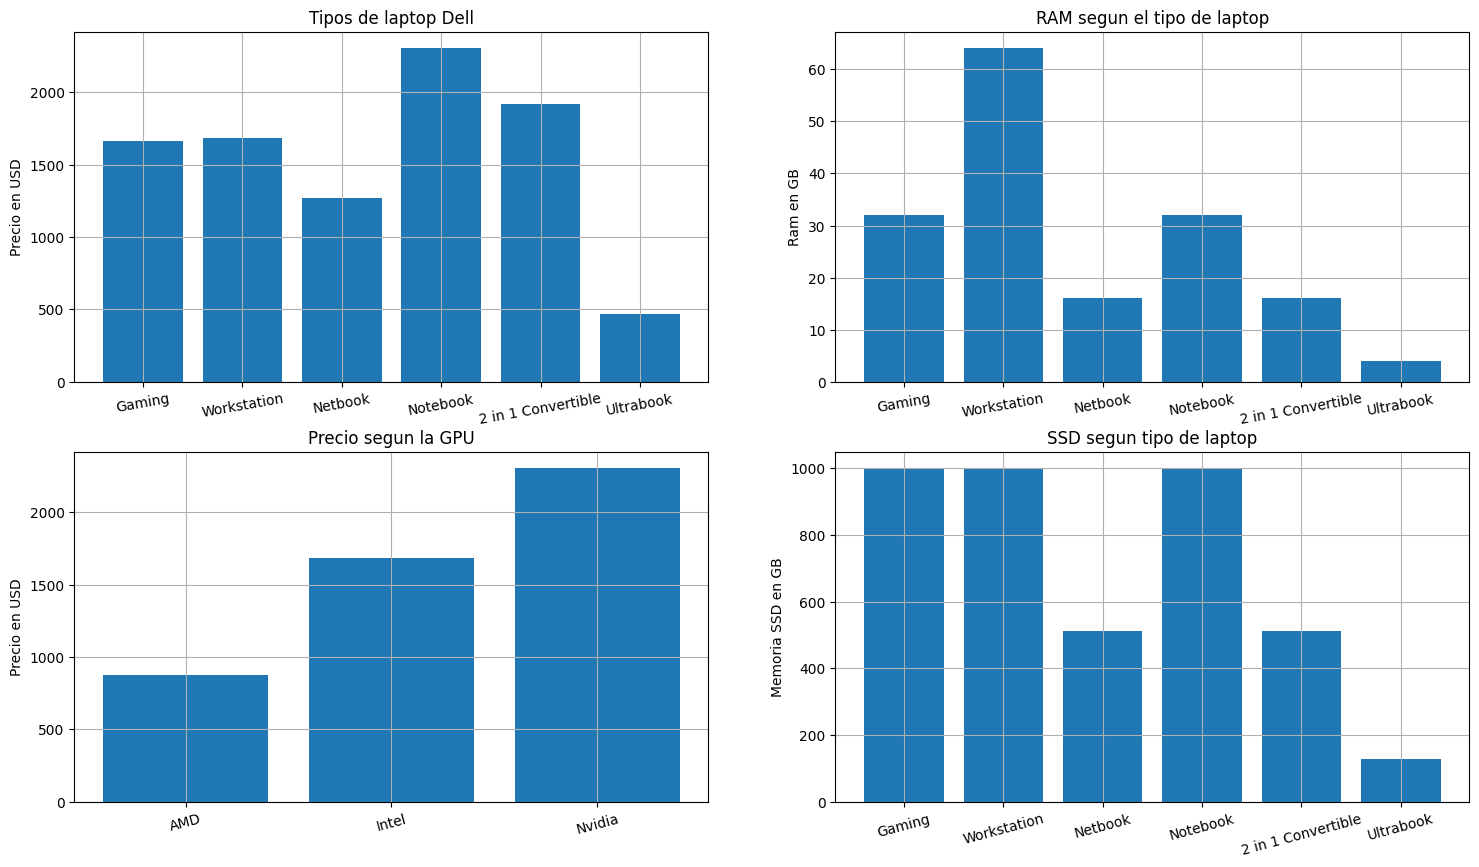

In [176]:
# Matplotlib
#Usando matplotlib
XTN = df_dell["TypeName"]
YP = df_dell["Price"]
YRAM = df_dell["Ram"]
XGPU = df_dell["Gpu brand"]
XMEM = df_dell["SSD"]


fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(18, 10))

#Tipo de laptop/Precio
axs[0,0].bar(XTN, YP)
axs[0,0].set_title("Tipos de laptop Dell")
axs[0,0].set_xticklabels(set(df_dell["TypeName"]), rotation=10)
axs[0,0].set_ylabel("Precio en USD")
axs[0,0].grid(True)

#Tipo de laptop/RAM
axs[0,1].bar(XTN, YRAM)
axs[0,1].set_title("RAM segun el tipo de laptop")
axs[0,1].set_xticklabels(set(df_dell["TypeName"]), rotation=10)
axs[0,1].set_ylabel("Ram en GB")
axs[0,1].grid(True)


#Tipo de laptop/Gpu brand
axs[1,0].bar(XGPU, YP)
axs[1,0].set_title("Precio segun la GPU")
axs[1,0].set_xticklabels(set(df_dell["Gpu brand"]), rotation=15)
axs[1,0].set_ylabel("Precio en USD")
axs[1,0].grid(True)

#Tipo de memoria/precio
axs[1,1].bar(XTN, XMEM)
axs[1,1].set_title("SSD segun tipo de laptop")
axs[1,1].set_xticklabels(set(df_dell["TypeName"]), rotation=15)
axs[1,1].set_ylabel("Memoria SSD en GB")
axs[1,1].grid(True)


C:\Users\USUARIO\AppData\Local\Temp\ipykernel_29648\968108491.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(df_dell, x=XTN_SNS, y=YP_SNS, jitter=True,
C:\Users\USUARIO\AppData\Local\Temp\ipykernel_29648\968108491.py:11: FutureWarning: Use "auto" to set automatic grayscale colors. From v0.14.0, "gray" will default to matplotlib's definition.
  sns.stripplot(df_dell, x=XTN_SNS, y=YP_SNS, jitter=True,


<Axes: xlabel='TypeName', ylabel='Ram'>

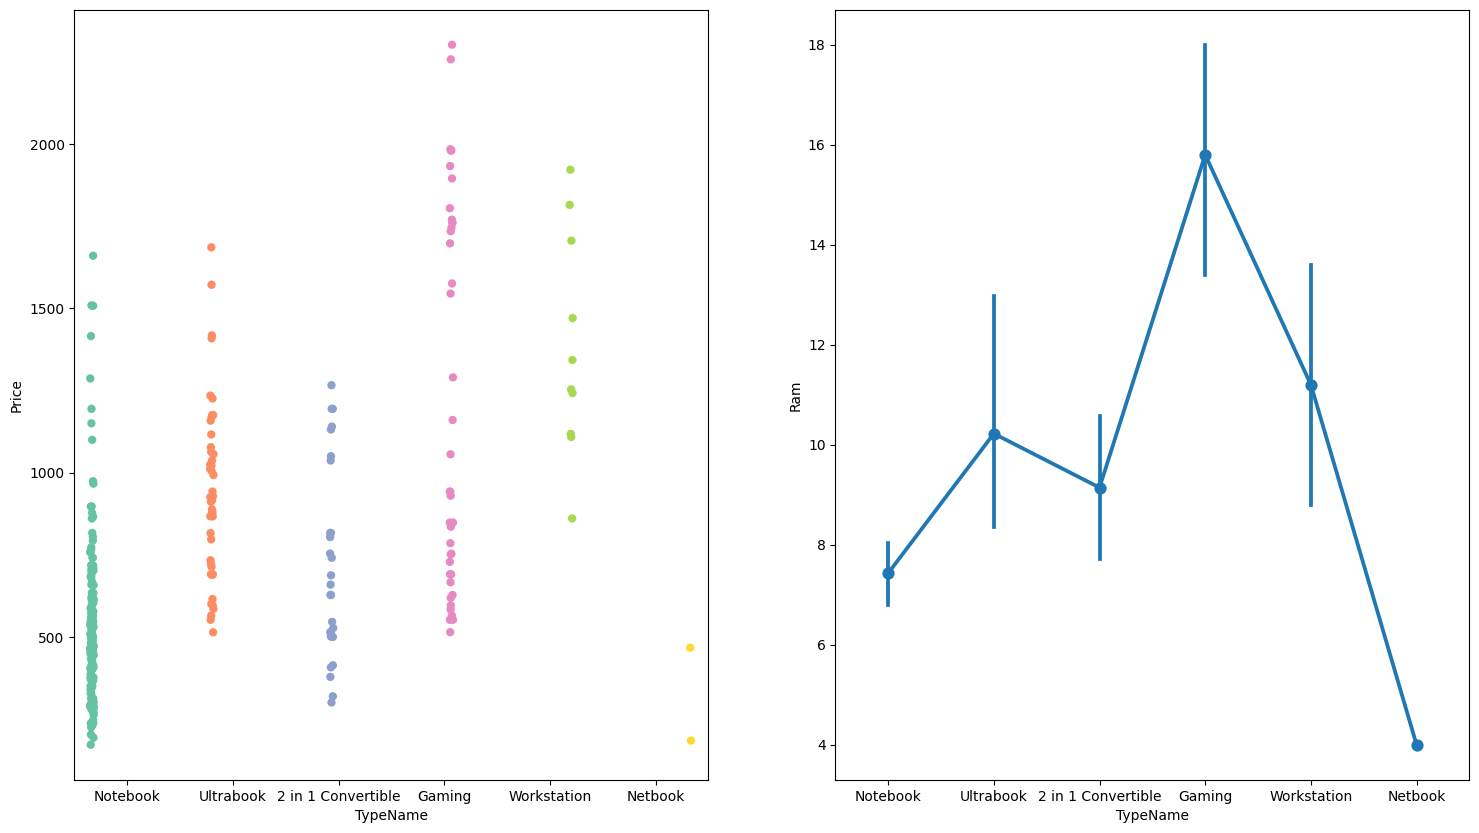

In [275]:
#Usando seaborn
XTN_SNS = df_dell["TypeName"]
YP_SNS = df_dell["Price"]
YRAM_SNS = df_dell["Ram"]
XGPU_SNS = df_dell["Gpu brand"]
XMEM_SNS = df_dell["SSD"]

fig, axs = plt.subplots(
    ncols=2, figsize=(18,10)
)
sns.stripplot(df_dell, x=XTN_SNS, y=YP_SNS, jitter=True,
              dodge=True, palette="Set2", size=6, edgecolor="gray", ax = axs[0])

sns.pointplot(df_dell, x=XTN_SNS, y=YRAM_SNS, ax = axs[1])



### HP

In [178]:
df_hp.sort_values("Price", ascending=False)

,Company,TypeName,Ram,Price,Touchscreen,Ips,ppi,Cpu brand,HDD,SSD,Hybrid,Flash_Storage,Gpu brand,os
726,HP,Workstation,16,2759.966471,0,1,127.335675,Other Intel Processor,0,256,0,0,Nvidia,Windows
1104,HP,Workstation,8,2483.529638,0,1,127.335675,Intel Core i7,0,256,0,0,Nvidia,Windows
885,HP,Ultrabook,8,1949.395320,1,0,352.465147,Other Intel Processor,0,240,0,0,Intel,Windows
1071,HP,Workstation,8,1822.999043,0,1,127.335675,Intel Core i7,1000,0,0,0,AMD,Windows
831,HP,2 in 1 Convertible,8,1609.194395,1,0,165.632118,Intel Core i7,0,256,0,0,Intel,Windows
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1136,HP,Notebook,2,156.580463,0,0,111.935204,Other Intel Processor,0,0,0,32,Intel,Windows
64,HP,Notebook,4,144.003719,0,0,111.935204,Other Intel Processor,0,32,0,0,Intel,Windows
1233,HP,Netbook,2,131.426975,0,0,135.094211,Other Intel Processor,0,0,0,32,Intel,Windows
1247,HP,Netbook,2,131.426975,0,0,135.094211,Other Intel Processor,0,0,0,32,Intel,Windows


C:\Users\USUARIO\AppData\Local\Temp\ipykernel_29648\2256628926.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[0,0].set_xticklabels(set(df_hp["TypeName"]), rotation=10)
C:\Users\USUARIO\AppData\Local\Temp\ipykernel_29648\2256628926.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[0,1].set_xticklabels(set(df_hp["TypeName"]), rotation=10)
C:\Users\USUARIO\AppData\Local\Temp\ipykernel_29648\2256628926.py:29: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[1,0].set_xticklabels(set(df_hp["Gpu brand"]), rotation=15)
C:\Users\USUARIO\AppData\Local\Temp\ipykernel_29648\2256628926.py:36: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[1,1].set_

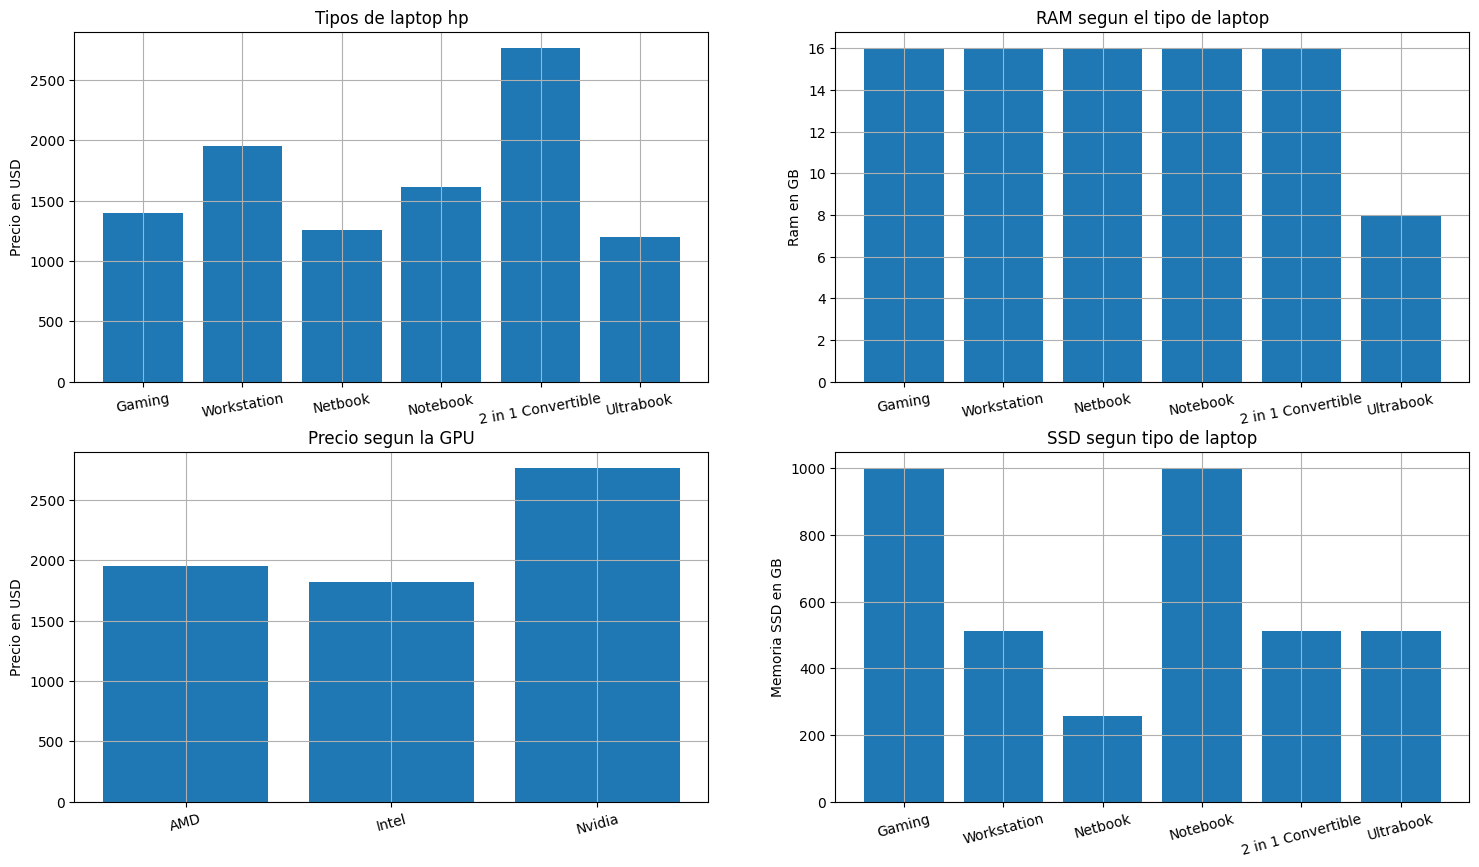

In [179]:
#Usando matplotlib
XTN = df_hp["TypeName"]
YP = df_hp["Price"]
YRAM = df_hp["Ram"]
XGPU = df_hp["Gpu brand"]
XMEM = df_hp["SSD"]


fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(18, 10))

#Tipo de laptop/Precio
axs[0,0].bar(XTN, YP)
axs[0,0].set_title("Tipos de laptop hp")
axs[0,0].set_xticklabels(set(df_hp["TypeName"]), rotation=10)
axs[0,0].set_ylabel("Precio en USD")
axs[0,0].grid(True)

#Tipo de laptop/RAM
axs[0,1].bar(XTN, YRAM)
axs[0,1].set_title("RAM segun el tipo de laptop")
axs[0,1].set_xticklabels(set(df_hp["TypeName"]), rotation=10)
axs[0,1].set_ylabel("Ram en GB")
axs[0,1].grid(True)


#Tipo de laptop/Gpu brand
axs[1,0].bar(XGPU, YP)
axs[1,0].set_title("Precio segun la GPU")
axs[1,0].set_xticklabels(set(df_hp["Gpu brand"]), rotation=15)
axs[1,0].set_ylabel("Precio en USD")
axs[1,0].grid(True)

#Tipo de memoria/precio
axs[1,1].bar(XTN, XMEM)
axs[1,1].set_title("SSD segun tipo de laptop")
axs[1,1].set_xticklabels(set(df_hp["TypeName"]), rotation=15)
axs[1,1].set_ylabel("Memoria SSD en GB")
axs[1,1].grid(True)

C:\Users\USUARIO\AppData\Local\Temp\ipykernel_29648\1250064579.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(df_hp, x=XTN_SNS, y=YP_SNS, jitter=True,
C:\Users\USUARIO\AppData\Local\Temp\ipykernel_29648\1250064579.py:11: FutureWarning: Use "auto" to set automatic grayscale colors. From v0.14.0, "gray" will default to matplotlib's definition.
  sns.stripplot(df_hp, x=XTN_SNS, y=YP_SNS, jitter=True,


<Axes: xlabel='TypeName', ylabel='Ram'>

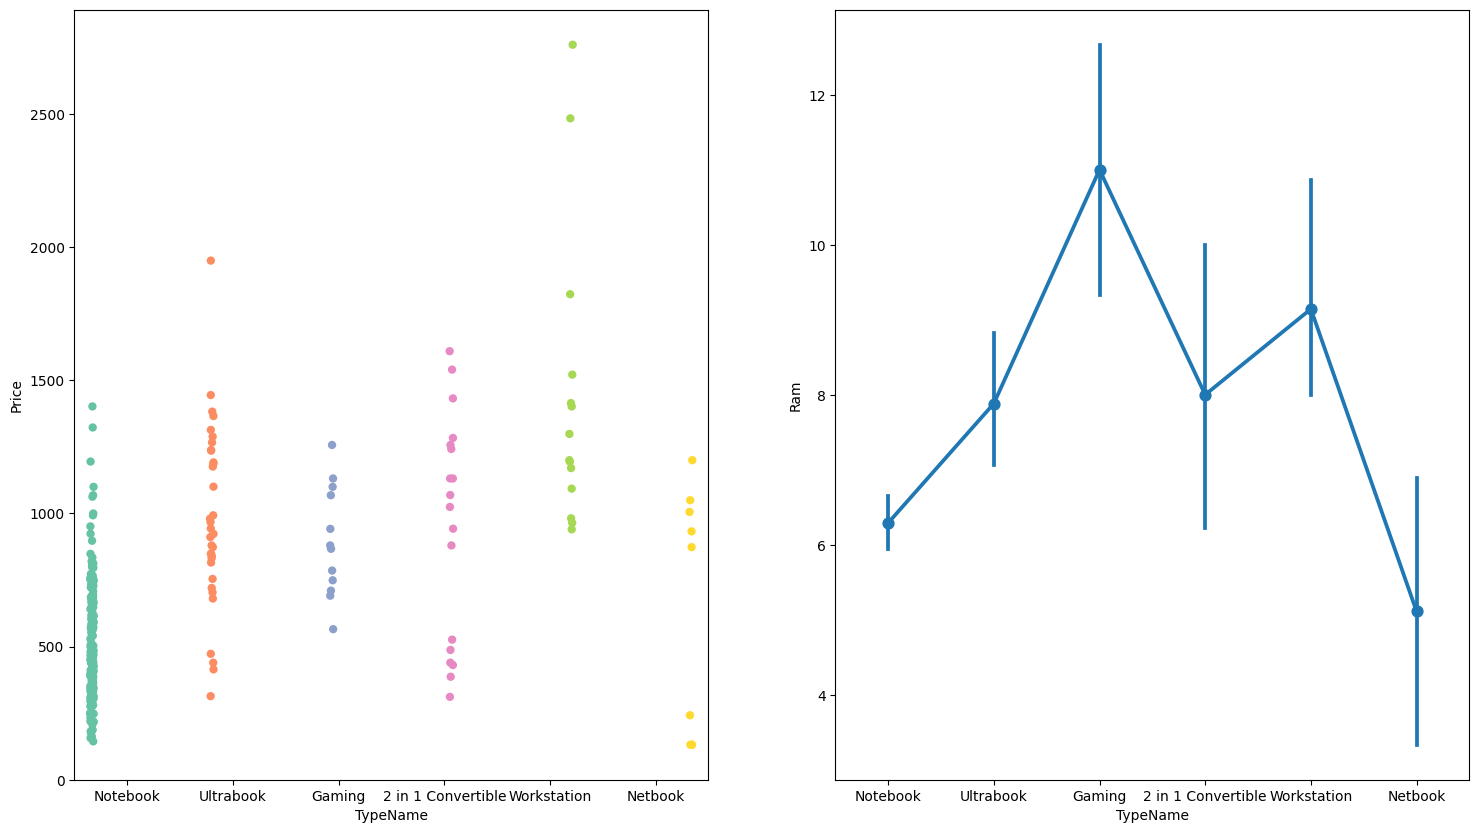

In [278]:
#Usando seaborn
XTN_SNS = df_hp["TypeName"]
YP_SNS = df_hp["Price"]
YRAM_SNS = df_hp["Ram"]
XGPU_SNS = df_hp["Gpu brand"]
XMEM_SNS = df_hp["SSD"]

fig, axs = plt.subplots(
    ncols=2, figsize=(18,10)
)
sns.stripplot(df_hp, x=XTN_SNS, y=YP_SNS, jitter=True,
              dodge=True, palette="Set2", size=6, edgecolor="gray", ax = axs[0])

sns.pointplot(df_hp, x=XTN_SNS, y=YRAM_SNS, ax = axs[1])



### ASUS

In [180]:
df_asus.sort_values("Price", ascending=False)

,Company,TypeName,Ram,Price,Touchscreen,Ips,ppi,Cpu brand,HDD,SSD,Hybrid,Flash_Storage,Gpu brand,os
1034,Asus,Gaming,64,2499.627870,0,1,127.335675,Intel Core i7,0,1000,0,0,Nvidia,Windows
229,Asus,Gaming,32,2446.176708,0,0,127.335675,Intel Core i7,1000,512,0,0,Nvidia,Windows
238,Asus,Gaming,16,1885.882763,0,0,127.335675,Intel Core i7,0,256,0,0,Nvidia,Windows
502,Asus,Gaming,24,1866.388810,0,0,141.211998,Intel Core i7,0,512,0,0,Nvidia,Windows
631,Asus,Gaming,32,1760.115323,0,1,127.335675,Intel Core i7,0,512,0,0,Nvidia,Windows
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
304,Asus,2 in 1 Convertible,2,172.930230,1,0,135.094211,Other Intel Processor,0,0,0,32,Intel,Windows
327,Asus,Notebook,4,172.923942,0,0,100.454670,Other Intel Processor,1000,0,0,0,Intel,Others/No OS/Linux
500,Asus,Netbook,2,154.065114,0,0,135.094211,Other Intel Processor,0,0,0,32,Intel,Windows
540,Asus,Notebook,4,140.859533,0,0,100.454670,Other Intel Processor,500,0,0,0,Intel,Others/No OS/Linux


C:\Users\USUARIO\AppData\Local\Temp\ipykernel_29648\3245144560.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[0,0].set_xticklabels(set(df_asus["TypeName"]), rotation=10)
C:\Users\USUARIO\AppData\Local\Temp\ipykernel_29648\3245144560.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[0,1].set_xticklabels(set(df_asus["TypeName"]), rotation=10)
C:\Users\USUARIO\AppData\Local\Temp\ipykernel_29648\3245144560.py:29: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[1,0].set_xticklabels(set(df_asus["Gpu brand"]), rotation=15)
C:\Users\USUARIO\AppData\Local\Temp\ipykernel_29648\3245144560.py:36: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[1,1

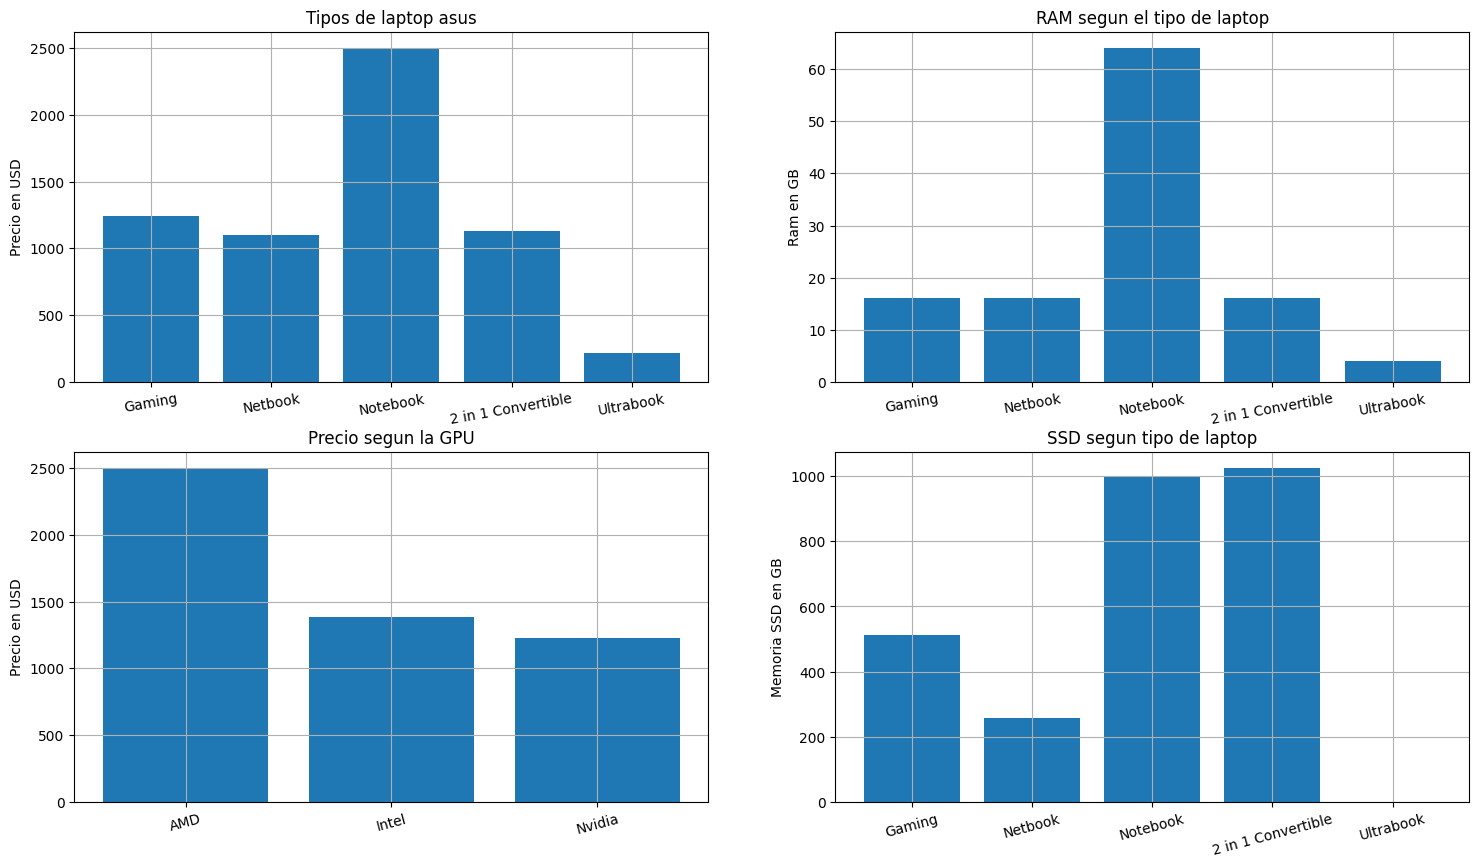

In [181]:
#Usando matplotlib
XTN = df_asus["TypeName"]
YP = df_asus["Price"]
YRAM = df_asus["Ram"]
XGPU = df_asus["Gpu brand"]
XMEM = df_asus["SSD"]


fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(18, 10))

#Tipo de laptop/Precio
axs[0,0].bar(XTN, YP)
axs[0,0].set_title("Tipos de laptop asus")
axs[0,0].set_xticklabels(set(df_asus["TypeName"]), rotation=10)
axs[0,0].set_ylabel("Precio en USD")
axs[0,0].grid(True)

#Tipo de laptop/RAM
axs[0,1].bar(XTN, YRAM)
axs[0,1].set_title("RAM segun el tipo de laptop")
axs[0,1].set_xticklabels(set(df_asus["TypeName"]), rotation=10)
axs[0,1].set_ylabel("Ram en GB")
axs[0,1].grid(True)


#Tipo de laptop/Gpu brand
axs[1,0].bar(XGPU, YP)
axs[1,0].set_title("Precio segun la GPU")
axs[1,0].set_xticklabels(set(df_asus["Gpu brand"]), rotation=15)
axs[1,0].set_ylabel("Precio en USD")
axs[1,0].grid(True)

#Tipo de memoria/precio
axs[1,1].bar(XTN, XMEM)
axs[1,1].set_title("SSD segun tipo de laptop")
axs[1,1].set_xticklabels(set(df_asus["TypeName"]), rotation=15)
axs[1,1].set_ylabel("Memoria SSD en GB")
axs[1,1].grid(True)

C:\Users\USUARIO\AppData\Local\Temp\ipykernel_29648\910447194.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(df_asus, x=XTN_SNS, y=YP_SNS, jitter=True,
C:\Users\USUARIO\AppData\Local\Temp\ipykernel_29648\910447194.py:11: FutureWarning: Use "auto" to set automatic grayscale colors. From v0.14.0, "gray" will default to matplotlib's definition.
  sns.stripplot(df_asus, x=XTN_SNS, y=YP_SNS, jitter=True,


<Axes: xlabel='TypeName', ylabel='Ram'>

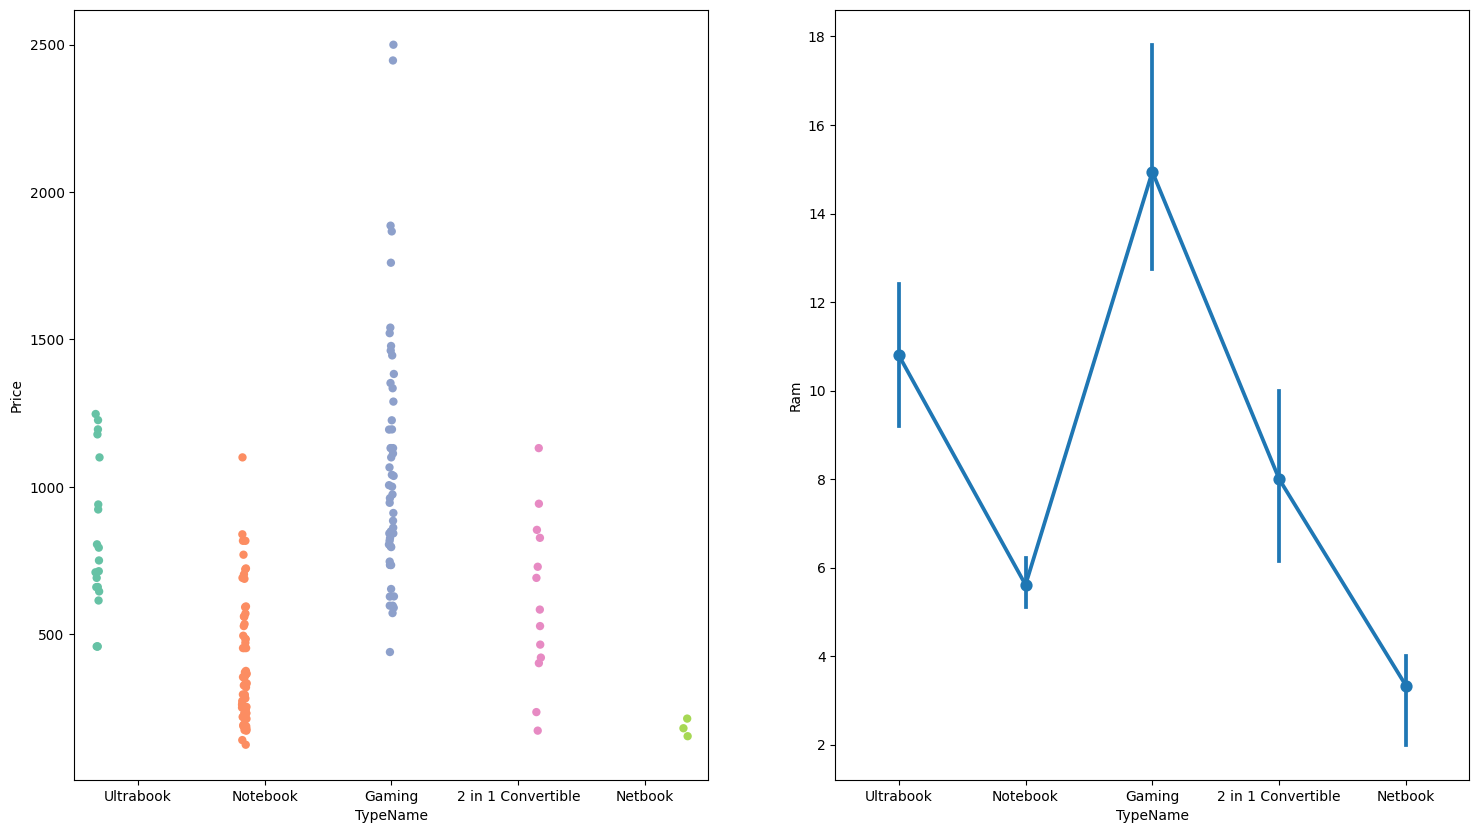

In [279]:
#Usando seaborn
XTN_SNS = df_asus["TypeName"]
YP_SNS = df_asus["Price"]
YRAM_SNS = df_asus["Ram"]
XGPU_SNS = df_asus["Gpu brand"]
XMEM_SNS = df_asus["SSD"]

fig, axs = plt.subplots(
    ncols=2, figsize=(18,10)
)
sns.stripplot(df_asus, x=XTN_SNS, y=YP_SNS, jitter=True,
              dodge=True, palette="Set2", size=6, edgecolor="gray", ax = axs[0])

sns.pointplot(df_asus, x=XTN_SNS, y=YRAM_SNS, ax = axs[1])



### ACER

In [182]:
df_acer.sort_values("Price", ascending=False)

,Company,TypeName,Ram,Price,Touchscreen,Ips,ppi,Cpu brand,HDD,SSD,Hybrid,Flash_Storage,Gpu brand,os
1157,Acer,Gaming,16,1634.347883,0,1,127.335675,Intel Core i7,1000,256,0,0,Nvidia,Windows
762,Acer,Gaming,16,1445.696723,0,1,127.335675,Intel Core i7,1000,256,0,0,Nvidia,Windows
708,Acer,Gaming,16,1216.799982,0,1,127.335675,Intel Core i7,1000,128,0,0,Nvidia,Windows
659,Acer,Gaming,16,816.859523,0,0,141.211998,Intel Core i5,0,256,0,0,Nvidia,Windows
969,Acer,Gaming,8,792.334872,0,1,141.211998,Intel Core i7,1000,128,0,0,Nvidia,Windows
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1165,Acer,Notebook,4,171.043718,0,0,100.454670,Other Intel Processor,1000,0,0,0,Intel,Others/No OS/Linux
675,Acer,Netbook,4,169.157207,0,0,135.094211,Other Intel Processor,0,0,0,32,Intel,Windows
1070,Acer,Notebook,4,131.426975,0,0,100.454670,Other Intel Processor,0,16,0,0,Intel,Others/No OS/Linux
280,Acer,Notebook,2,125.138603,0,0,100.454670,Other Intel Processor,0,16,0,0,Intel,Others/No OS/Linux


C:\Users\USUARIO\AppData\Local\Temp\ipykernel_29648\1887169614.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[0,0].set_xticklabels(set(df_acer["TypeName"]), rotation=10)
C:\Users\USUARIO\AppData\Local\Temp\ipykernel_29648\1887169614.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[0,1].set_xticklabels(set(df_acer["TypeName"]), rotation=10)
C:\Users\USUARIO\AppData\Local\Temp\ipykernel_29648\1887169614.py:29: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[1,0].set_xticklabels(set(df_acer["Gpu brand"]), rotation=15)
C:\Users\USUARIO\AppData\Local\Temp\ipykernel_29648\1887169614.py:36: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[1,1

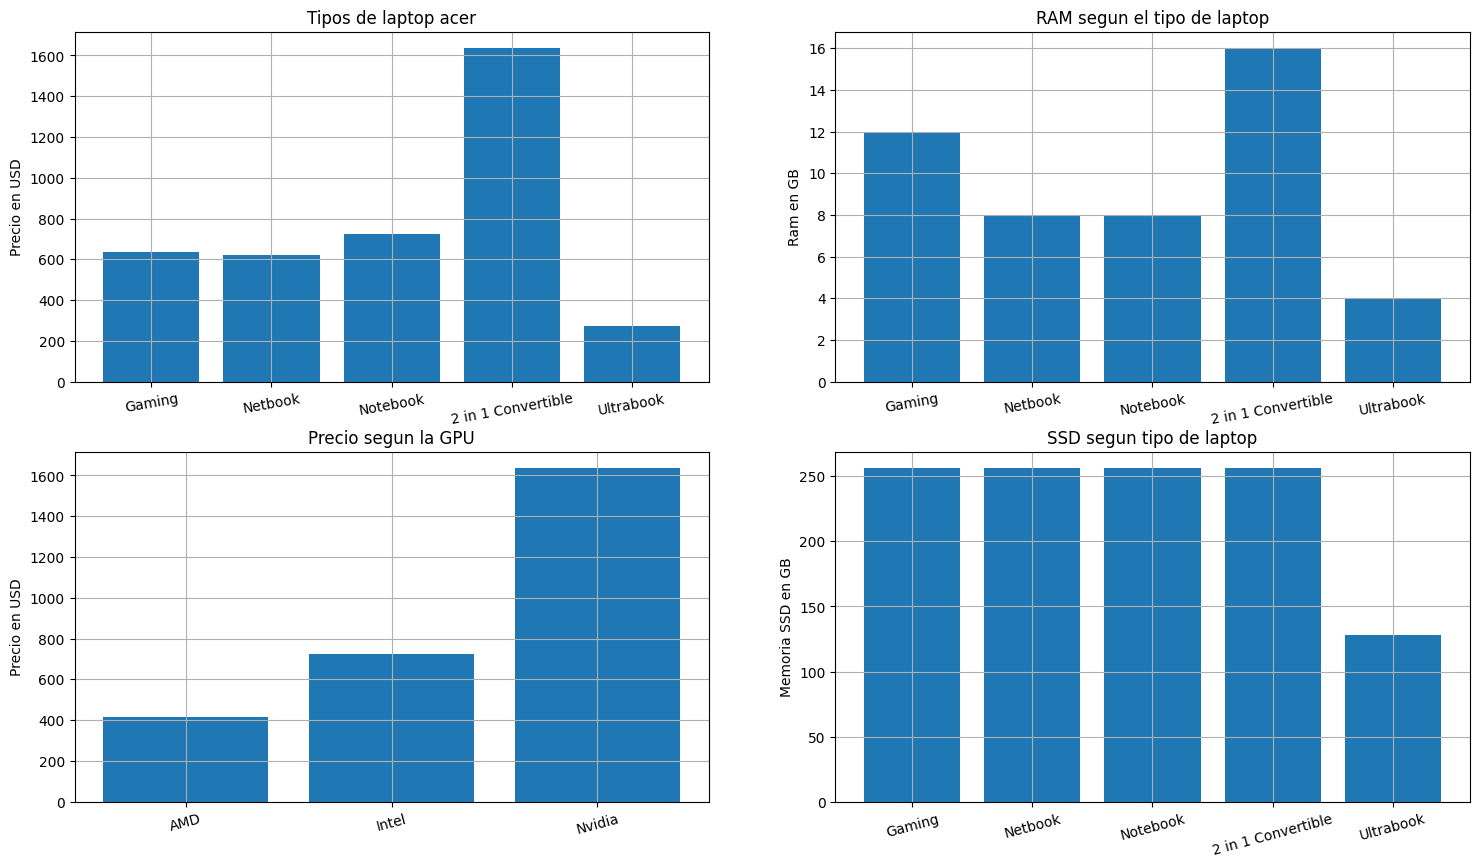

In [183]:
#Usando matplotlib
XTN = df_acer["TypeName"]
YP = df_acer["Price"]
YRAM = df_acer["Ram"]
XGPU = df_acer["Gpu brand"]
XMEM = df_acer["SSD"]


fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(18, 10))

#Tipo de laptop/Precio
axs[0,0].bar(XTN, YP)
axs[0,0].set_title("Tipos de laptop acer")
axs[0,0].set_xticklabels(set(df_acer["TypeName"]), rotation=10)
axs[0,0].set_ylabel("Precio en USD")
axs[0,0].grid(True)

#Tipo de laptop/RAM
axs[0,1].bar(XTN, YRAM)
axs[0,1].set_title("RAM segun el tipo de laptop")
axs[0,1].set_xticklabels(set(df_acer["TypeName"]), rotation=10)
axs[0,1].set_ylabel("Ram en GB")
axs[0,1].grid(True)


#Tipo de laptop/Gpu brand
axs[1,0].bar(XGPU, YP)
axs[1,0].set_title("Precio segun la GPU")
axs[1,0].set_xticklabels(set(df_acer["Gpu brand"]), rotation=15)
axs[1,0].set_ylabel("Precio en USD")
axs[1,0].grid(True)

#Tipo de memoria/precio
axs[1,1].bar(XTN, XMEM)
axs[1,1].set_title("SSD segun tipo de laptop")
axs[1,1].set_xticklabels(set(df_acer["TypeName"]), rotation=15)
axs[1,1].set_ylabel("Memoria SSD en GB")
axs[1,1].grid(True)

C:\Users\USUARIO\AppData\Local\Temp\ipykernel_29648\3732709446.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(df_acer, x=XTN_SNS, y=YP_SNS, jitter=True,
C:\Users\USUARIO\AppData\Local\Temp\ipykernel_29648\3732709446.py:11: FutureWarning: Use "auto" to set automatic grayscale colors. From v0.14.0, "gray" will default to matplotlib's definition.
  sns.stripplot(df_acer, x=XTN_SNS, y=YP_SNS, jitter=True,


<Axes: xlabel='TypeName', ylabel='Ram'>

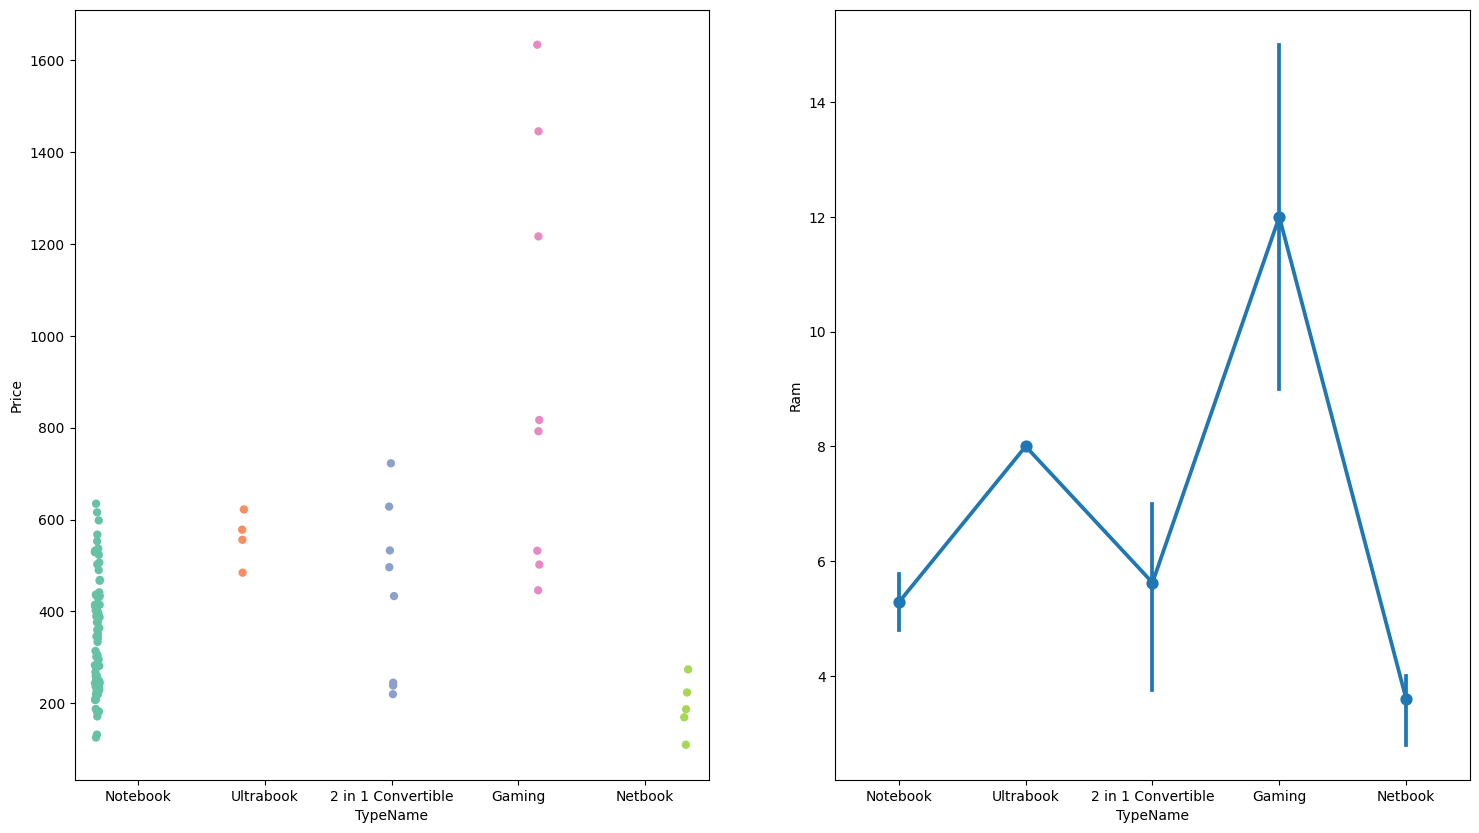

In [280]:
#Usando seaborn
XTN_SNS = df_acer["TypeName"]
YP_SNS = df_acer["Price"]
YRAM_SNS = df_acer["Ram"]
XGPU_SNS = df_acer["Gpu brand"]
XMEM_SNS = df_acer["SSD"]

fig, axs = plt.subplots(
    ncols=2, figsize=(18,10)
)
sns.stripplot(df_acer, x=XTN_SNS, y=YP_SNS, jitter=True,
              dodge=True, palette="Set2", size=6, edgecolor="gray", ax = axs[0])

sns.pointplot(df_acer, x=XTN_SNS, y=YRAM_SNS, ax = axs[1])



### MSI

In [184]:
df_msi.sort_values("Price", ascending=False)

,Company,TypeName,Ram,Price,Touchscreen,Ips,ppi,Cpu brand,HDD,SSD,Hybrid,Flash_Storage,Gpu brand,os
171,MSI,Gaming,32,1760.115323,0,0,119.723216,Intel Core i7,1000,512,0,0,Nvidia,Windows
562,MSI,Gaming,16,1716.096719,0,0,127.335675,Intel Core i7,1000,512,0,0,Nvidia,Windows
868,MSI,Gaming,16,1665.789743,0,1,254.671349,Intel Core i7,2000,512,0,0,Nvidia,Windows
1045,MSI,Gaming,16,1571.464163,0,0,127.335675,Intel Core i7,1000,256,0,0,Nvidia,Windows
249,MSI,Gaming,16,1571.464163,0,0,127.335675,Intel Core i7,1000,512,0,0,Nvidia,Windows
55,MSI,Gaming,16,1540.022303,0,0,127.335675,Intel Core i7,2000,256,0,0,Nvidia,Windows
785,MSI,Gaming,16,1518.641838,0,0,127.335675,Intel Core i7,1000,512,0,0,Nvidia,Windows
1106,MSI,Gaming,16,1508.580443,0,0,127.335675,Intel Core i7,1000,256,0,0,Nvidia,Windows
569,MSI,Gaming,16,1477.138583,0,0,127.335675,Intel Core i7,1000,128,0,0,Nvidia,Windows
589,MSI,Gaming,16,1445.696723,0,0,282.423996,Intel Core i7,2000,256,0,0,Nvidia,Windows


C:\Users\USUARIO\AppData\Local\Temp\ipykernel_29648\391670063.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[0,0].set_xticklabels(set(df_msi["TypeName"]), rotation=10)
C:\Users\USUARIO\AppData\Local\Temp\ipykernel_29648\391670063.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[0,1].set_xticklabels(set(df_msi["TypeName"]), rotation=10)
C:\Users\USUARIO\AppData\Local\Temp\ipykernel_29648\391670063.py:29: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[1,0].set_xticklabels(set(df_msi["Gpu brand"]), rotation=15)
C:\Users\USUARIO\AppData\Local\Temp\ipykernel_29648\391670063.py:36: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[1,1].set_x

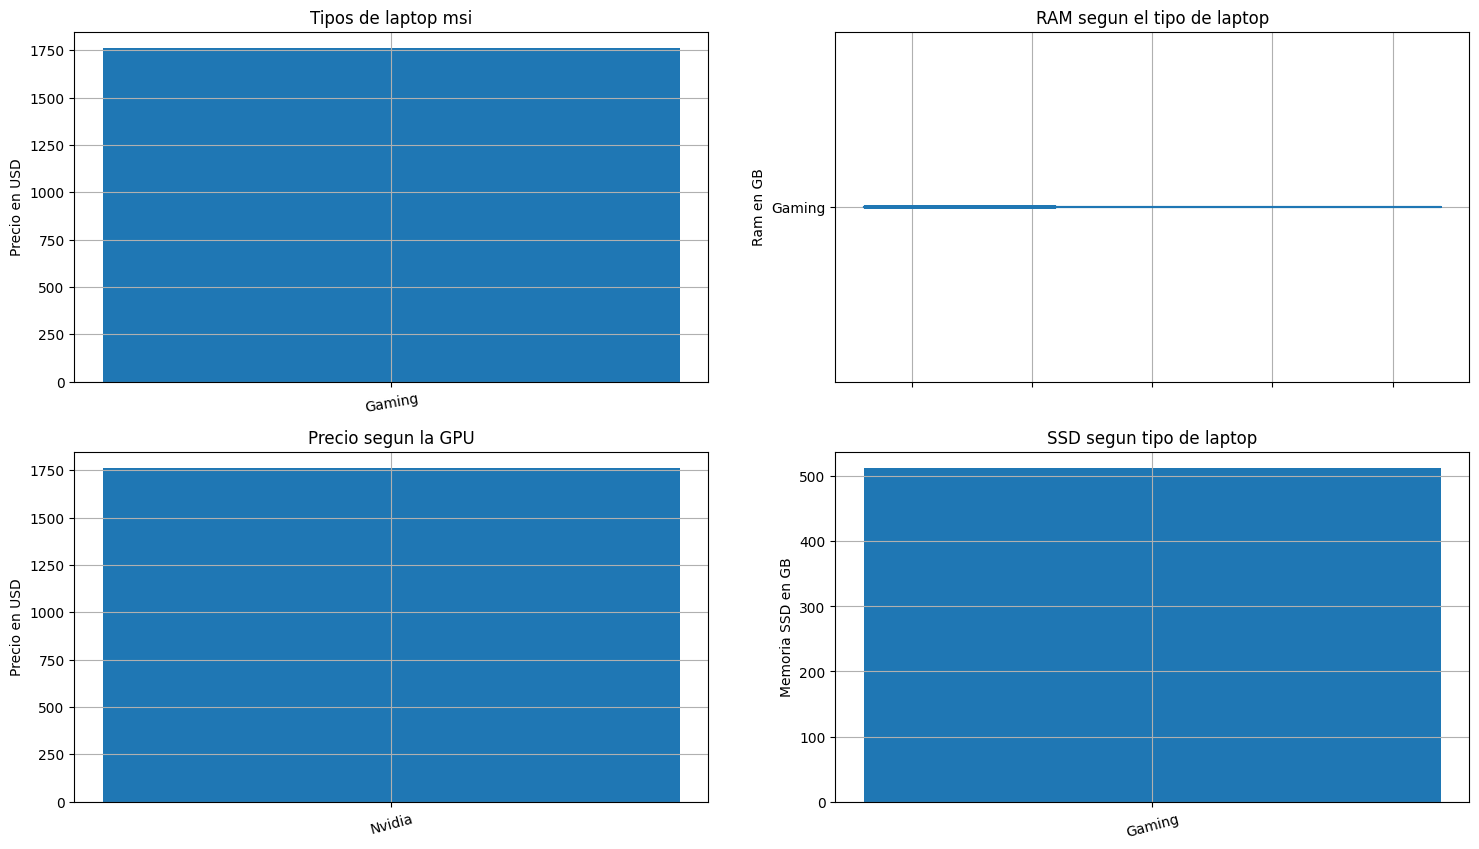

In [283]:
#Usando matplotlib
XTN = df_msi["TypeName"]
YP = df_msi["Price"]
YRAM = df_msi["Ram"]
XGPU = df_msi["Gpu brand"]
XMEM = df_msi["SSD"]


fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(18, 10))

#Tipo de laptop/Precio
axs[0,0].bar(XTN, YP)
axs[0,0].set_title("Tipos de laptop msi")
axs[0,0].set_xticklabels(set(df_msi["TypeName"]), rotation=10)
axs[0,0].set_ylabel("Precio en USD")
axs[0,0].grid(True)

#Tipo de laptop/RAM
axs[0,1].plot(YRAM, XTN)
axs[0,1].set_title("RAM segun el tipo de laptop")
axs[0,1].set_xticklabels(set(df_msi["TypeName"]), rotation=10)
axs[0,1].set_ylabel("Ram en GB")
axs[0,1].grid(True)


#Tipo de laptop/Gpu brand
axs[1,0].bar(XGPU, YP)
axs[1,0].set_title("Precio segun la GPU")
axs[1,0].set_xticklabels(set(df_msi["Gpu brand"]), rotation=15)
axs[1,0].set_ylabel("Precio en USD")
axs[1,0].grid(True)

#Tipo de memoria/precio
axs[1,1].bar(XTN, XMEM)
axs[1,1].set_title("SSD segun tipo de laptop")
axs[1,1].set_xticklabels(set(df_msi["TypeName"]), rotation=15)
axs[1,1].set_ylabel("Memoria SSD en GB")
axs[1,1].grid(True)

### APPLE

In [186]:
df_apple.sort_values("Price", ascending=False)

,Company,TypeName,Ram,Price,Touchscreen,Ips,ppi,Cpu brand,HDD,SSD,Hybrid,Flash_Storage,Gpu brand,os
17,Apple,Ultrabook,16,1797.216718,0,1,220.534624,Intel Core i7,0,512,0,0,AMD,Mac
3,Apple,Ultrabook,16,1595.642953,0,1,220.534624,Intel Core i7,0,512,0,0,AMD,Mac
12,Apple,Ultrabook,16,1534.343903,0,1,220.534624,Intel Core i7,0,256,0,0,AMD,Mac
6,Apple,Ultrabook,16,1345.692743,0,1,220.534624,Intel Core i7,0,0,0,256,Intel,Mac
240,Apple,Ultrabook,8,1282.827888,0,1,226.983005,Intel Core i5,0,512,0,0,Intel,Mac
260,Apple,Ultrabook,8,1231.829191,0,1,226.983005,Intel Core i5,0,512,0,0,Intel,Mac
4,Apple,Ultrabook,8,1134.170774,0,1,226.983005,Intel Core i5,0,256,0,0,Intel,Mac
15,Apple,Ultrabook,8,954.920730,0,1,226.983005,Intel Core i5,0,256,0,0,Intel,Mac
78,Apple,Ultrabook,8,949.544172,0,1,226.415547,Intel Core i5,0,512,0,0,Intel,Mac
44,Apple,Ultrabook,8,892.319987,0,1,226.983005,Intel Core i5,0,256,0,0,Intel,Mac


C:\Users\USUARIO\AppData\Local\Temp\ipykernel_29648\3648202371.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[0,0].set_xticklabels(set(df_apple["TypeName"]), rotation=10)
C:\Users\USUARIO\AppData\Local\Temp\ipykernel_29648\3648202371.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[0,1].set_xticklabels(set(df_apple["TypeName"]), rotation=10)
C:\Users\USUARIO\AppData\Local\Temp\ipykernel_29648\3648202371.py:29: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[1,0].set_xticklabels(set(df_apple["Gpu brand"]), rotation=15)
C:\Users\USUARIO\AppData\Local\Temp\ipykernel_29648\3648202371.py:36: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[

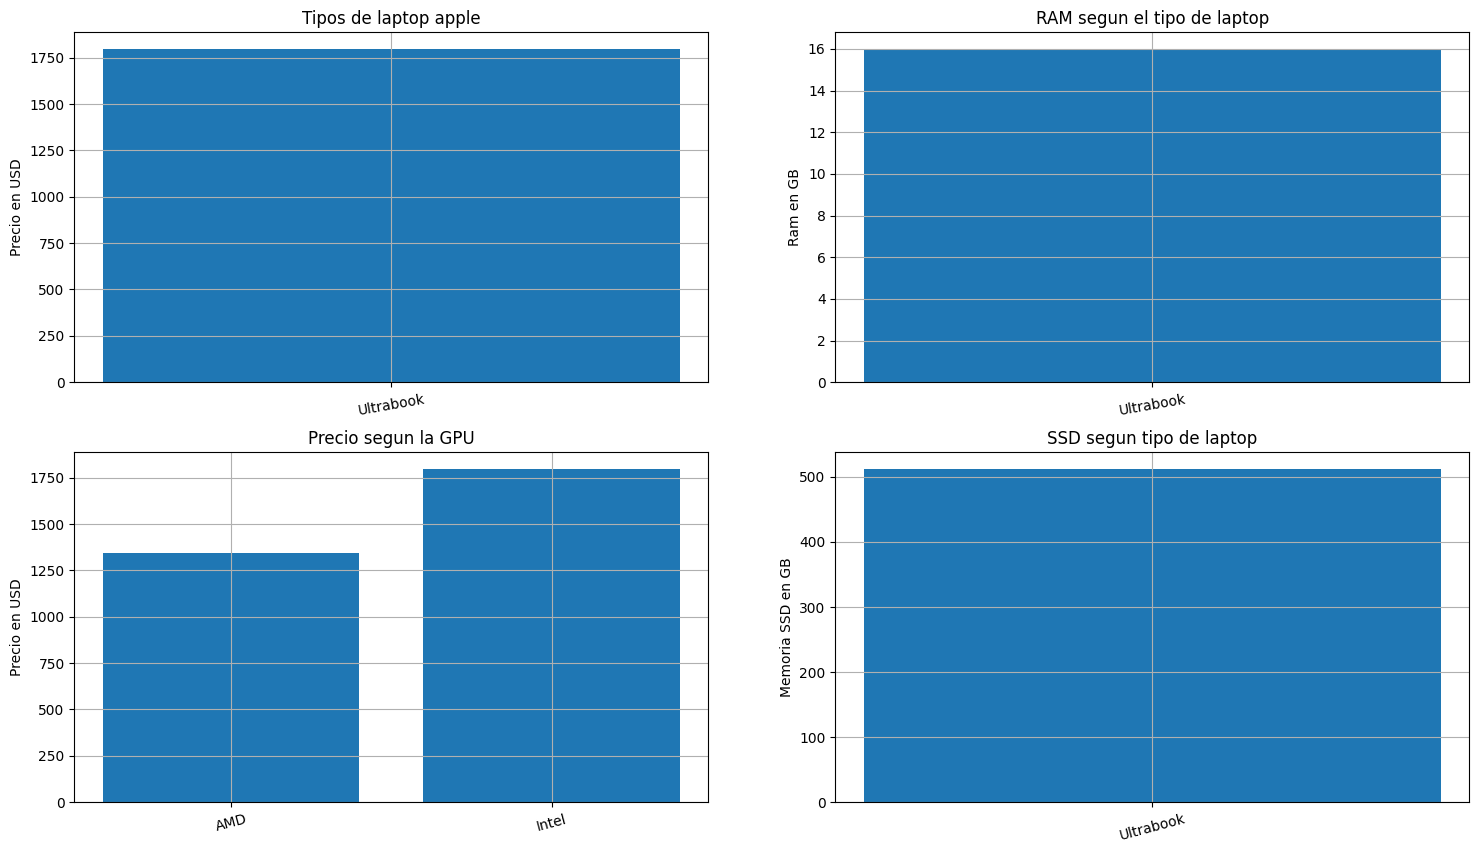

In [187]:
#Usando matplotlib
XTN = df_apple["TypeName"]
YP = df_apple["Price"]
YRAM = df_apple["Ram"]
XGPU = df_apple["Gpu brand"]
XMEM = df_apple["SSD"]


fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(18, 10))

#Tipo de laptop/Precio
axs[0,0].bar(XTN, YP)
axs[0,0].set_title("Tipos de laptop apple")
axs[0,0].set_xticklabels(set(df_apple["TypeName"]), rotation=10)
axs[0,0].set_ylabel("Precio en USD")
axs[0,0].grid(True)

#Tipo de laptop/RAM
axs[0,1].bar(XTN, YRAM)
axs[0,1].set_title("RAM segun el tipo de laptop")
axs[0,1].set_xticklabels(set(df_apple["TypeName"]), rotation=10)
axs[0,1].set_ylabel("Ram en GB")
axs[0,1].grid(True)


#Tipo de laptop/Gpu brand
axs[1,0].bar(XGPU, YP)
axs[1,0].set_title("Precio segun la GPU")
axs[1,0].set_xticklabels(set(df_apple["Gpu brand"]), rotation=15)
axs[1,0].set_ylabel("Precio en USD")
axs[1,0].grid(True)

#Tipo de memoria/precio
axs[1,1].bar(XTN, XMEM)
axs[1,1].set_title("SSD segun tipo de laptop")
axs[1,1].set_xticklabels(set(df_apple["TypeName"]), rotation=15)
axs[1,1].set_ylabel("Memoria SSD en GB")
axs[1,1].grid(True)

### SAMSUNG

In [188]:
df_samsung.sort_values("Price", ascending=False)

,Company,TypeName,Ram,Price,Touchscreen,Ips,ppi,Cpu brand,HDD,SSD,Hybrid,Flash_Storage,Gpu brand,os
848,Samsung,Ultrabook,16,1162.719983,0,0,146.860478,Intel Core i7,0,256,0,0,Nvidia,Windows
746,Samsung,2 in 1 Convertible,16,1131.278123,1,0,146.860478,Intel Core i7,0,256,0,0,AMD,Windows
577,Samsung,Notebook,16,1068.394403,0,0,141.211998,Intel Core i7,1000,128,0,0,Nvidia,Windows
866,Samsung,Ultrabook,8,1068.394403,0,0,146.860478,Intel Core i7,0,256,0,0,Intel,Windows
724,Samsung,Ultrabook,16,1036.952543,0,0,165.632118,Intel Core i7,0,256,0,0,Intel,Windows
744,Samsung,Ultrabook,8,1005.510683,1,0,165.632118,Intel Core i7,0,256,0,0,Intel,Windows
786,Samsung,Ultrabook,8,942.626963,0,0,165.632118,Intel Core i5,0,256,0,0,Intel,Windows
417,Samsung,Netbook,4,169.157207,0,0,135.094211,Other Intel Processor,0,0,0,16,Intel,Others/No OS/Linux


C:\Users\USUARIO\AppData\Local\Temp\ipykernel_29648\1902920025.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[0,0].set_xticklabels(set(df_samsung["TypeName"]), rotation=10)
C:\Users\USUARIO\AppData\Local\Temp\ipykernel_29648\1902920025.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[0,1].set_xticklabels(set(df_samsung["TypeName"]), rotation=10)
C:\Users\USUARIO\AppData\Local\Temp\ipykernel_29648\1902920025.py:29: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[1,0].set_xticklabels(set(df_samsung["Gpu brand"]), rotation=15)
C:\Users\USUARIO\AppData\Local\Temp\ipykernel_29648\1902920025.py:36: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.


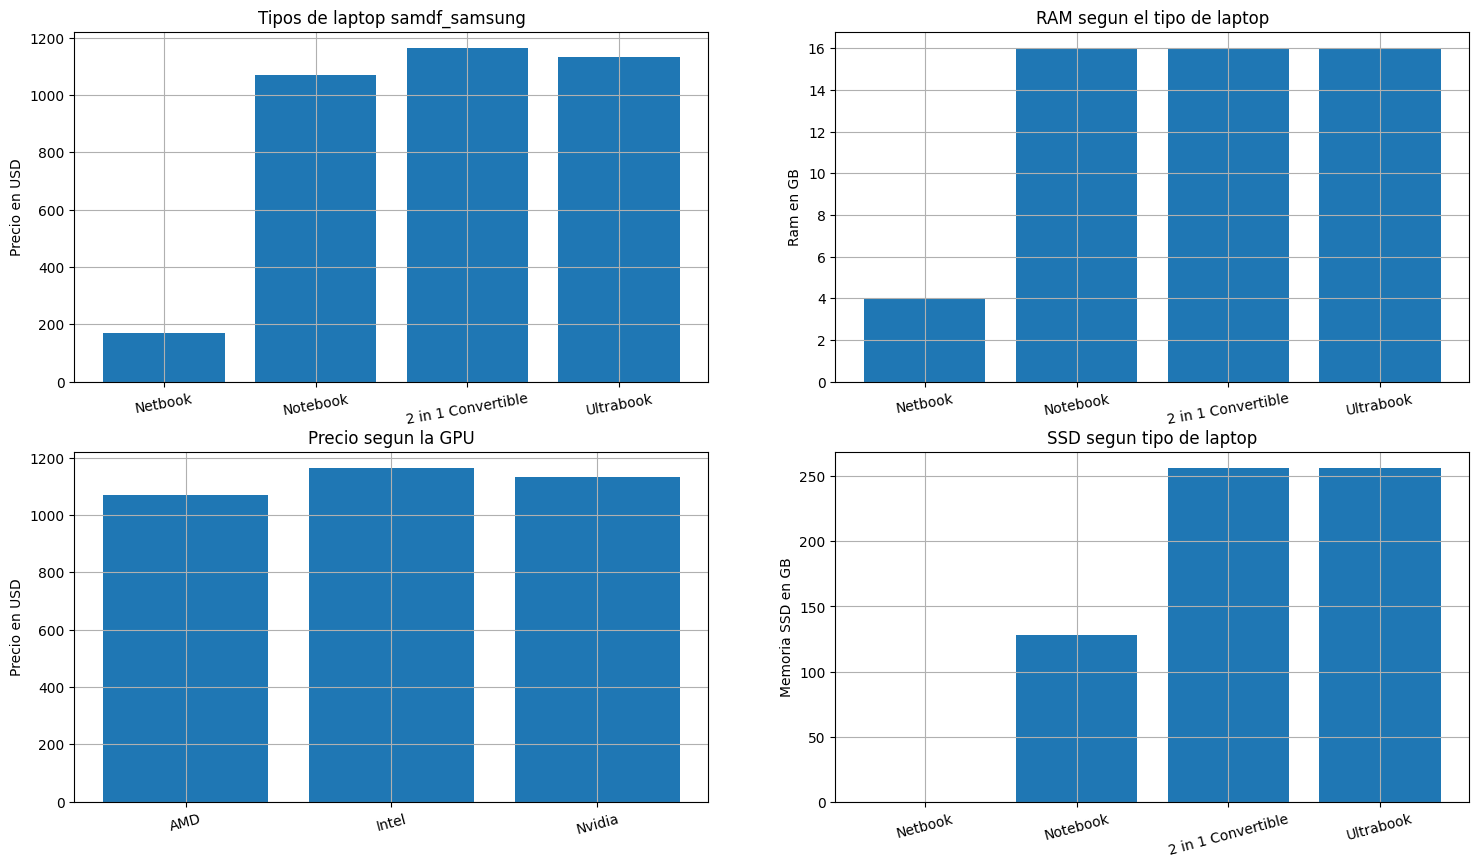

In [189]:
#Usando matplotlib
XTN = df_samsung["TypeName"]
YP = df_samsung["Price"]
YRAM = df_samsung["Ram"]
XGPU = df_samsung["Gpu brand"]
XMEM = df_samsung["SSD"]


fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(18, 10))

#Tipo de laptop/Precio
axs[0,0].bar(XTN, YP)
axs[0,0].set_title("Tipos de laptop samdf_samsung")
axs[0,0].set_xticklabels(set(df_samsung["TypeName"]), rotation=10)
axs[0,0].set_ylabel("Precio en USD")
axs[0,0].grid(True)

#Tipo de laptop/RAM
axs[0,1].bar(XTN, YRAM)
axs[0,1].set_title("RAM segun el tipo de laptop")
axs[0,1].set_xticklabels(set(df_samsung["TypeName"]), rotation=10)
axs[0,1].set_ylabel("Ram en GB")
axs[0,1].grid(True)


#Tipo de laptop/Gpu brand
axs[1,0].bar(XGPU, YP)
axs[1,0].set_title("Precio segun la GPU")
axs[1,0].set_xticklabels(set(df_samsung["Gpu brand"]), rotation=15)
axs[1,0].set_ylabel("Precio en USD")
axs[1,0].grid(True)

#Tipo de memoria/precio
axs[1,1].bar(XTN, XMEM)
axs[1,1].set_title("SSD segun tipo de laptop")
axs[1,1].set_xticklabels(set(df_samsung["TypeName"]), rotation=15)
axs[1,1].set_ylabel("Memoria SSD en GB")
axs[1,1].grid(True)

### MEDIACOM

In [190]:
df_mediacom.sort_values("Price", ascending=False)

,Company,TypeName,Ram,Price,Touchscreen,Ips,ppi,Cpu brand,HDD,SSD,Hybrid,Flash_Storage,Gpu brand,os
564,Mediacom,Notebook,4,244.617671,0,1,157.350512,Other Intel Processor,0,32,0,0,Intel,Windows
518,Mediacom,Notebook,4,232.040927,0,1,165.632118,Other Intel Processor,0,32,0,0,Intel,Windows
416,Mediacom,2 in 1 Convertible,4,188.022323,1,1,189.905791,Other Intel Processor,0,32,0,0,Intel,Windows
697,Mediacom,Notebook,4,166.641858,0,1,161.725391,Other Intel Processor,32,0,0,0,Intel,Windows
541,Mediacom,Notebook,4,160.353486,0,1,165.632118,Other Intel Processor,0,0,0,32,Intel,Windows
559,Mediacom,Notebook,4,156.580463,0,0,157.350512,Other Intel Processor,0,32,0,0,Intel,Windows
608,Mediacom,Notebook,2,150.292091,0,0,157.350512,Other Intel Processor,0,0,0,32,Intel,Windows


C:\Users\USUARIO\AppData\Local\Temp\ipykernel_29648\3722460360.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[0,0].set_xticklabels(set(df_mediacom["TypeName"]), rotation=10)
C:\Users\USUARIO\AppData\Local\Temp\ipykernel_29648\3722460360.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[0,1].set_xticklabels(set(df_mediacom["TypeName"]), rotation=10)
C:\Users\USUARIO\AppData\Local\Temp\ipykernel_29648\3722460360.py:29: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[1,0].set_xticklabels(set(df_mediacom["Gpu brand"]), rotation=15)
C:\Users\USUARIO\AppData\Local\Temp\ipykernel_29648\3722460360.py:36: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocato

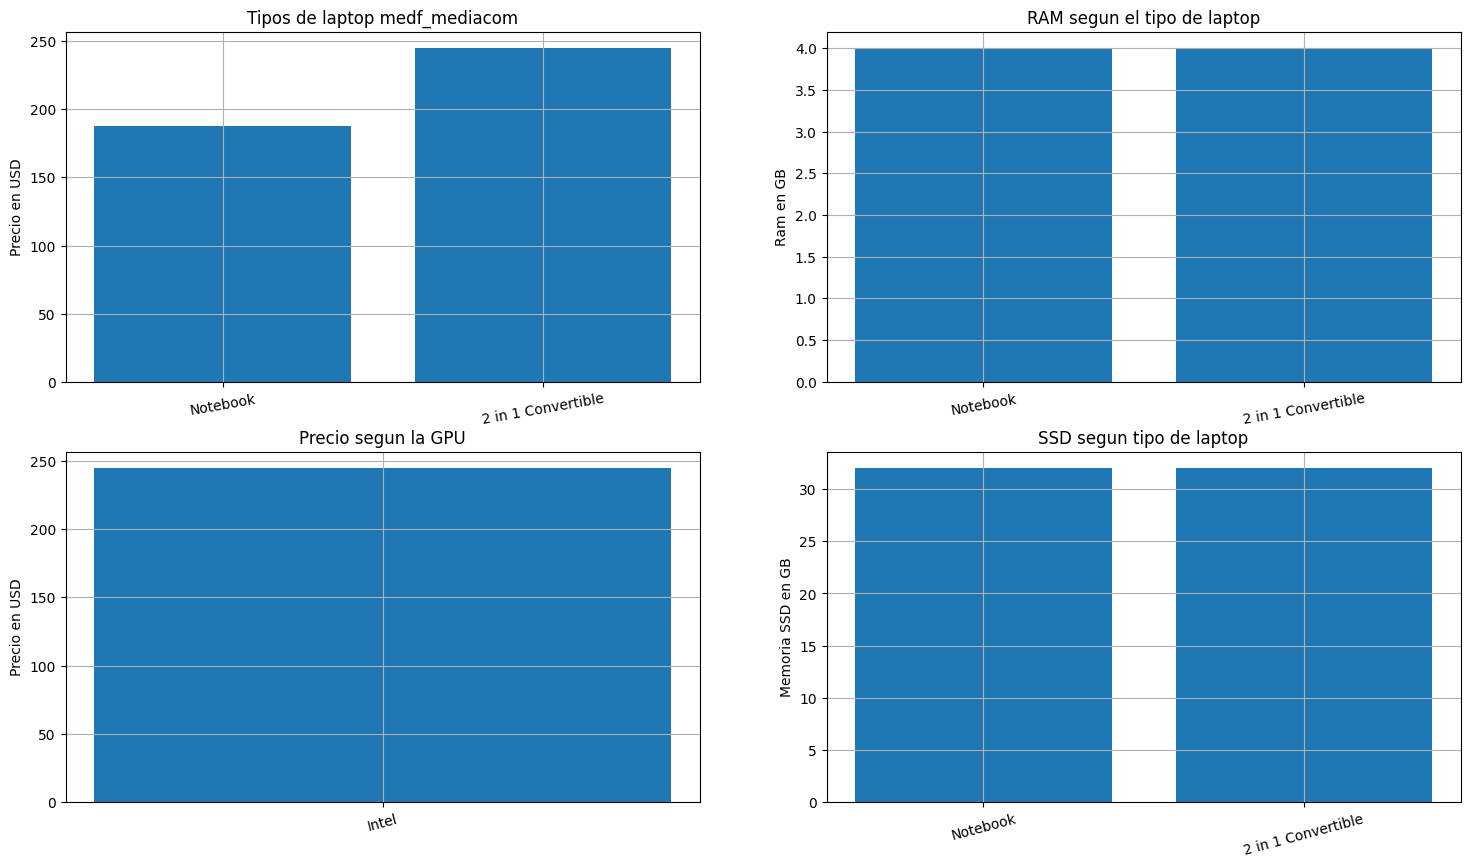

In [191]:
#Usando matplotlib
XTN = df_mediacom["TypeName"]
YP = df_mediacom["Price"]
YRAM = df_mediacom["Ram"]
XGPU = df_mediacom["Gpu brand"]
XMEM = df_mediacom["SSD"]


fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(18, 10))

#Tipo de laptop/Precio
axs[0,0].bar(XTN, YP)
axs[0,0].set_title("Tipos de laptop medf_mediacom")
axs[0,0].set_xticklabels(set(df_mediacom["TypeName"]), rotation=10)
axs[0,0].set_ylabel("Precio en USD")
axs[0,0].grid(True)

#Tipo de laptop/RAM
axs[0,1].bar(XTN, YRAM)
axs[0,1].set_title("RAM segun el tipo de laptop")
axs[0,1].set_xticklabels(set(df_mediacom["TypeName"]), rotation=10)
axs[0,1].set_ylabel("Ram en GB")
axs[0,1].grid(True)


#Tipo de laptop/Gpu brand
axs[1,0].bar(XGPU, YP)
axs[1,0].set_title("Precio segun la GPU")
axs[1,0].set_xticklabels(set(df_mediacom["Gpu brand"]), rotation=15)
axs[1,0].set_ylabel("Precio en USD")
axs[1,0].grid(True)

#Tipo de memoria/precio
axs[1,1].bar(XTN, XMEM)
axs[1,1].set_title("SSD segun tipo de laptop")
axs[1,1].set_xticklabels(set(df_mediacom["TypeName"]), rotation=15)
axs[1,1].set_ylabel("Memoria SSD en GB")
axs[1,1].grid(True)

### RAZER

In [192]:
df_razer.sort_values("Price", ascending=False)

,Company,TypeName,Ram,Price,Touchscreen,Ips,ppi,Cpu brand,HDD,SSD,Hybrid,Flash_Storage,Gpu brand,os
189,Razer,Gaming,32,3835.278083,1,0,254.671349,Intel Core i7,0,1000,0,0,Nvidia,Windows
804,Razer,Gaming,32,3457.975763,1,0,254.671349,Intel Core i7,0,512,0,0,Nvidia,Windows
1197,Razer,Gaming,16,2200.301363,0,0,157.350512,Intel Core i7,0,1000,0,0,Nvidia,Windows
752,Razer,Gaming,16,1822.999043,0,0,157.350512,Intel Core i7,0,512,0,0,Nvidia,Windows
628,Razer,Gaming,16,1634.347883,0,0,157.350512,Intel Core i7,0,256,0,0,Nvidia,Windows
790,Razer,Ultrabook,16,1131.278123,1,1,352.465147,Intel Core i7,0,512,0,0,Intel,Windows
1085,Razer,Ultrabook,8,647.073479,1,0,352.465147,Intel Core i7,0,256,0,0,Intel,Windows


C:\Users\USUARIO\AppData\Local\Temp\ipykernel_29648\355696182.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[0,0].set_xticklabels(set(df_razer["TypeName"]), rotation=10)
C:\Users\USUARIO\AppData\Local\Temp\ipykernel_29648\355696182.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[0,1].set_xticklabels(set(df_razer["TypeName"]), rotation=10)
C:\Users\USUARIO\AppData\Local\Temp\ipykernel_29648\355696182.py:29: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[1,0].set_xticklabels(set(df_razer["Gpu brand"]), rotation=15)
C:\Users\USUARIO\AppData\Local\Temp\ipykernel_29648\355696182.py:36: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[1,1]

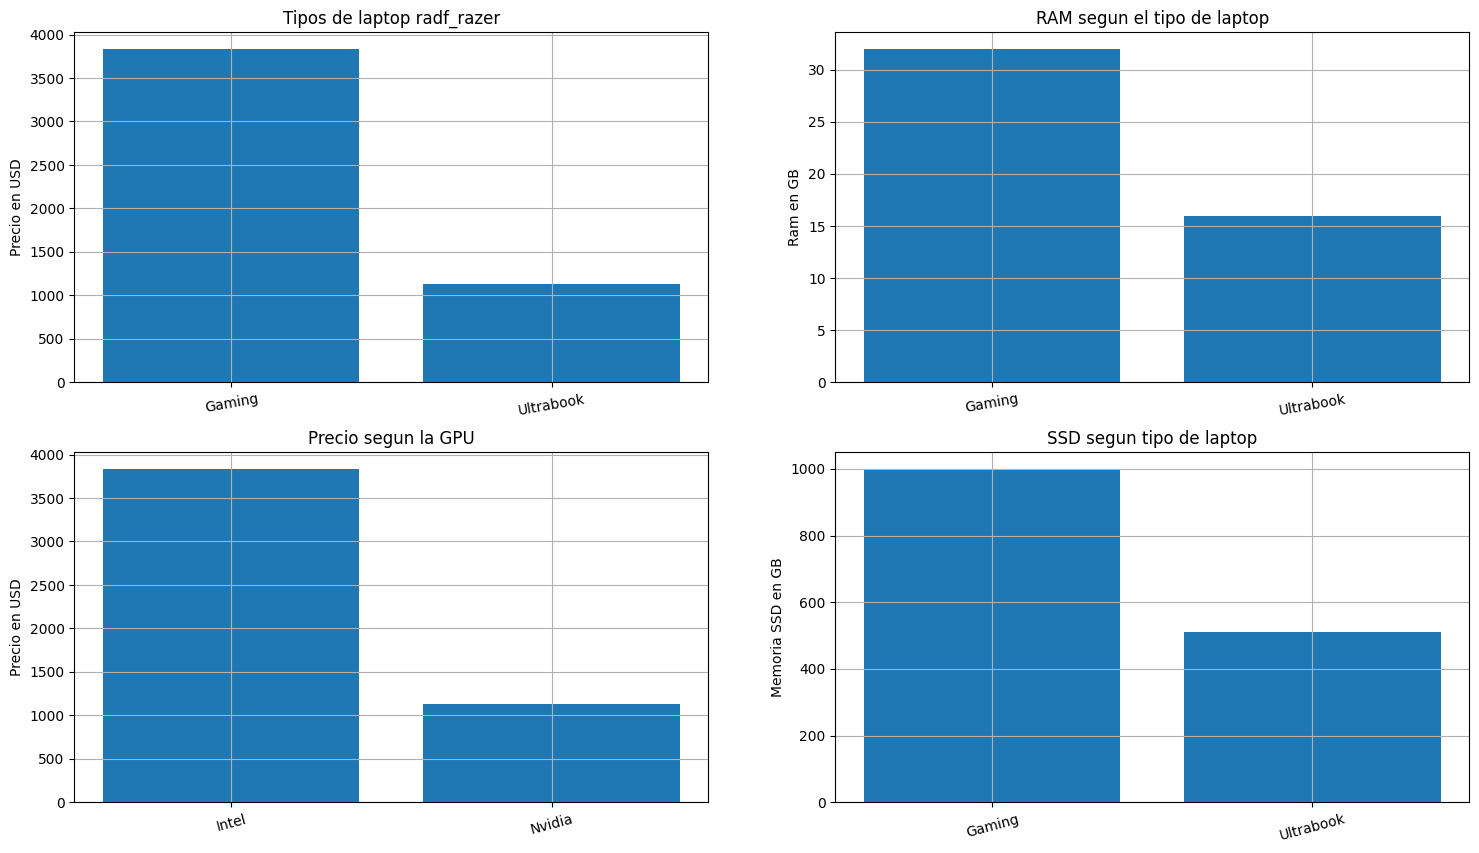

In [193]:
#Usando matplotlib
XTN = df_razer["TypeName"]
YP = df_razer["Price"]
YRAM = df_razer["Ram"]
XGPU = df_razer["Gpu brand"]
XMEM = df_razer["SSD"]


fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(18, 10))

#Tipo de laptop/Precio
axs[0,0].bar(XTN, YP)
axs[0,0].set_title("Tipos de laptop radf_razer")
axs[0,0].set_xticklabels(set(df_razer["TypeName"]), rotation=10)
axs[0,0].set_ylabel("Precio en USD")
axs[0,0].grid(True)

#Tipo de laptop/RAM
axs[0,1].bar(XTN, YRAM)
axs[0,1].set_title("RAM segun el tipo de laptop")
axs[0,1].set_xticklabels(set(df_razer["TypeName"]), rotation=10)
axs[0,1].set_ylabel("Ram en GB")
axs[0,1].grid(True)


#Tipo de laptop/Gpu brand
axs[1,0].bar(XGPU, YP)
axs[1,0].set_title("Precio segun la GPU")
axs[1,0].set_xticklabels(set(df_razer["Gpu brand"]), rotation=15)
axs[1,0].set_ylabel("Precio en USD")
axs[1,0].grid(True)

#Tipo de memoria/precio
axs[1,1].bar(XTN, XMEM)
axs[1,1].set_title("SSD segun tipo de laptop")
axs[1,1].set_xticklabels(set(df_razer["TypeName"]), rotation=15)
axs[1,1].set_ylabel("Memoria SSD en GB")
axs[1,1].grid(True)

### MICROSOFT

In [194]:
df_microsoft.sort_values("Price", ascending=False)

,Company,TypeName,Ram,Price,Touchscreen,Ips,ppi,Cpu brand,HDD,SSD,Hybrid,Flash_Storage,Gpu brand,os
436,Microsoft,Ultrabook,16,1628.059511,1,0,200.842560,Intel Core i7,0,512,0,0,Intel,Windows
650,Microsoft,Ultrabook,8,1174.573564,1,0,200.842560,Intel Core i7,0,256,0,0,Intel,Windows
445,Microsoft,Ultrabook,8,1131.278123,1,0,80.936554,Intel Core i7,0,256,0,0,Intel,Windows
101,Microsoft,Ultrabook,8,842.641848,1,0,200.842560,Intel Core i5,0,256,0,0,Intel,Windows
67,Microsoft,Ultrabook,4,684.803711,1,0,200.842560,Intel Core i5,0,128,0,0,Intel,Windows
444,Microsoft,Ultrabook,4,621.919991,1,0,200.842560,Other Intel Processor,0,128,0,0,Intel,Windows


C:\Users\USUARIO\AppData\Local\Temp\ipykernel_29648\275658351.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[0,0].set_xticklabels(set(df_microsoft["TypeName"]), rotation=10)
C:\Users\USUARIO\AppData\Local\Temp\ipykernel_29648\275658351.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[0,1].set_xticklabels(set(df_microsoft["TypeName"]), rotation=10)
C:\Users\USUARIO\AppData\Local\Temp\ipykernel_29648\275658351.py:29: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[1,0].set_xticklabels(set(df_microsoft["Gpu brand"]), rotation=15)
C:\Users\USUARIO\AppData\Local\Temp\ipykernel_29648\275658351.py:36: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator

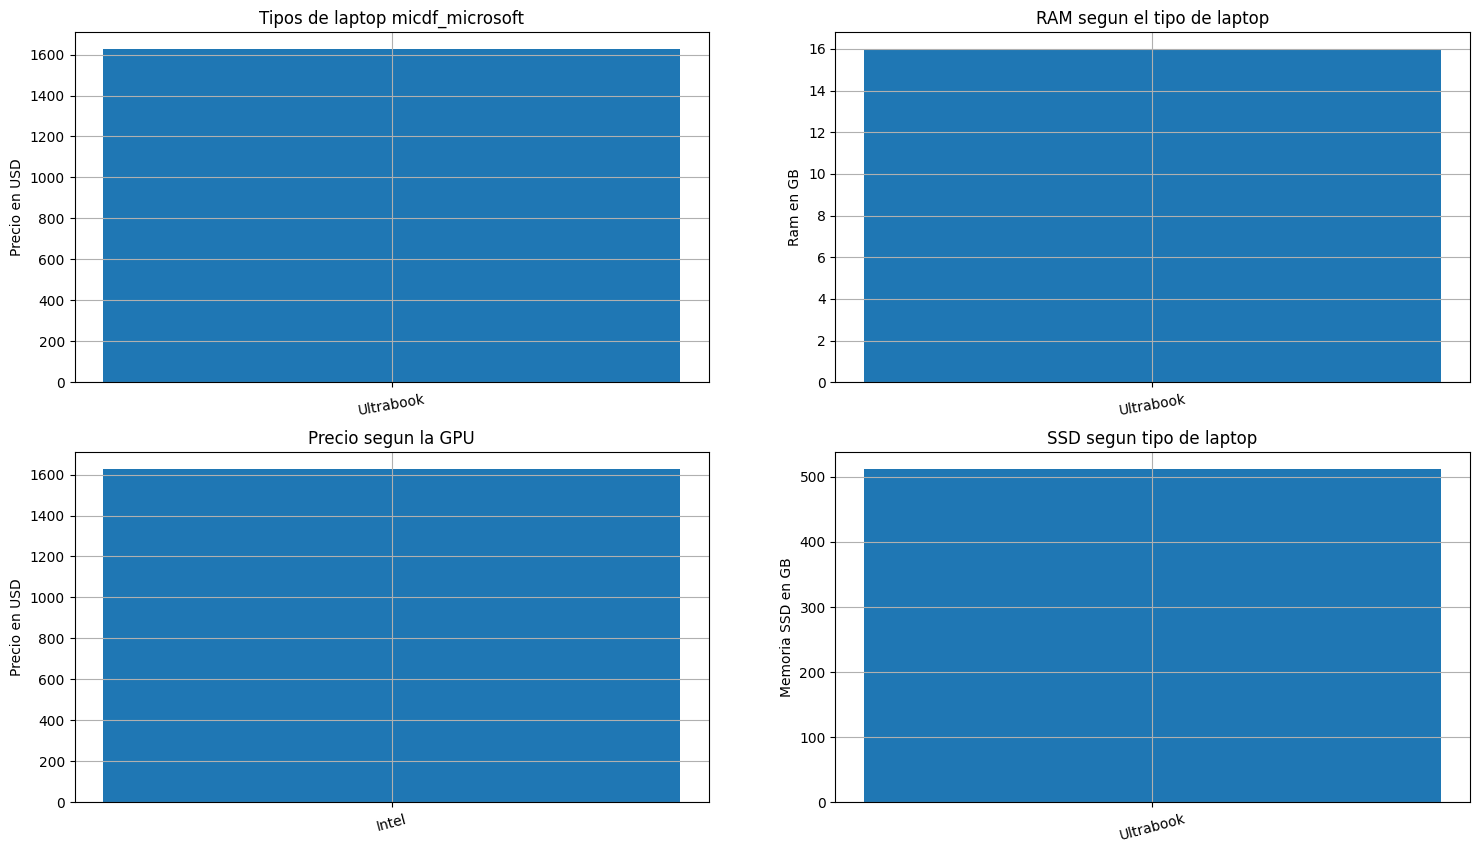

In [195]:
#Usando matplotlib
XTN = df_microsoft["TypeName"]
YP = df_microsoft["Price"]
YRAM = df_microsoft["Ram"]
XGPU = df_microsoft["Gpu brand"]
XMEM = df_microsoft["SSD"]


fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(18, 10))

#Tipo de laptop/Precio
axs[0,0].bar(XTN, YP)
axs[0,0].set_title("Tipos de laptop micdf_microsoft")
axs[0,0].set_xticklabels(set(df_microsoft["TypeName"]), rotation=10)
axs[0,0].set_ylabel("Precio en USD")
axs[0,0].grid(True)

#Tipo de laptop/RAM
axs[0,1].bar(XTN, YRAM)
axs[0,1].set_title("RAM segun el tipo de laptop")
axs[0,1].set_xticklabels(set(df_microsoft["TypeName"]), rotation=10)
axs[0,1].set_ylabel("Ram en GB")
axs[0,1].grid(True)


#Tipo de laptop/Gpu brand
axs[1,0].bar(XGPU, YP)
axs[1,0].set_title("Precio segun la GPU")
axs[1,0].set_xticklabels(set(df_microsoft["Gpu brand"]), rotation=15)
axs[1,0].set_ylabel("Precio en USD")
axs[1,0].grid(True)

#Tipo de memoria/precio
axs[1,1].bar(XTN, XMEM)
axs[1,1].set_title("SSD segun tipo de laptop")
axs[1,1].set_xticklabels(set(df_microsoft["TypeName"]), rotation=15)
axs[1,1].set_ylabel("Memoria SSD en GB")
axs[1,1].grid(True)

### VERO

In [196]:
df_vero.sort_values("Price", ascending=False)

,Company,TypeName,Ram,Price,Touchscreen,Ips,ppi,Cpu brand,HDD,SSD,Hybrid,Flash_Storage,Gpu brand,os
184,Vero,Notebook,4,163.497672,0,1,157.350512,Other Intel Processor,0,0,0,32,Intel,Windows
1010,Vero,Notebook,2,132.558882,0,0,111.935204,Other Intel Processor,0,0,0,32,Intel,Windows
765,Vero,Notebook,4,127.591068,0,0,157.350512,Other Intel Processor,0,0,0,32,Intel,Windows
1088,Vero,Notebook,4,123.252091,0,0,165.632118,Other Intel Processor,0,0,0,32,Intel,Windows


C:\Users\USUARIO\AppData\Local\Temp\ipykernel_29648\857224904.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[0,0].set_xticklabels(set(df_vero["TypeName"]), rotation=10)
C:\Users\USUARIO\AppData\Local\Temp\ipykernel_29648\857224904.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[0,1].set_xticklabels(set(df_vero["TypeName"]), rotation=10)
C:\Users\USUARIO\AppData\Local\Temp\ipykernel_29648\857224904.py:29: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[1,0].set_xticklabels(set(df_vero["Gpu brand"]), rotation=15)
C:\Users\USUARIO\AppData\Local\Temp\ipykernel_29648\857224904.py:36: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[1,1].se

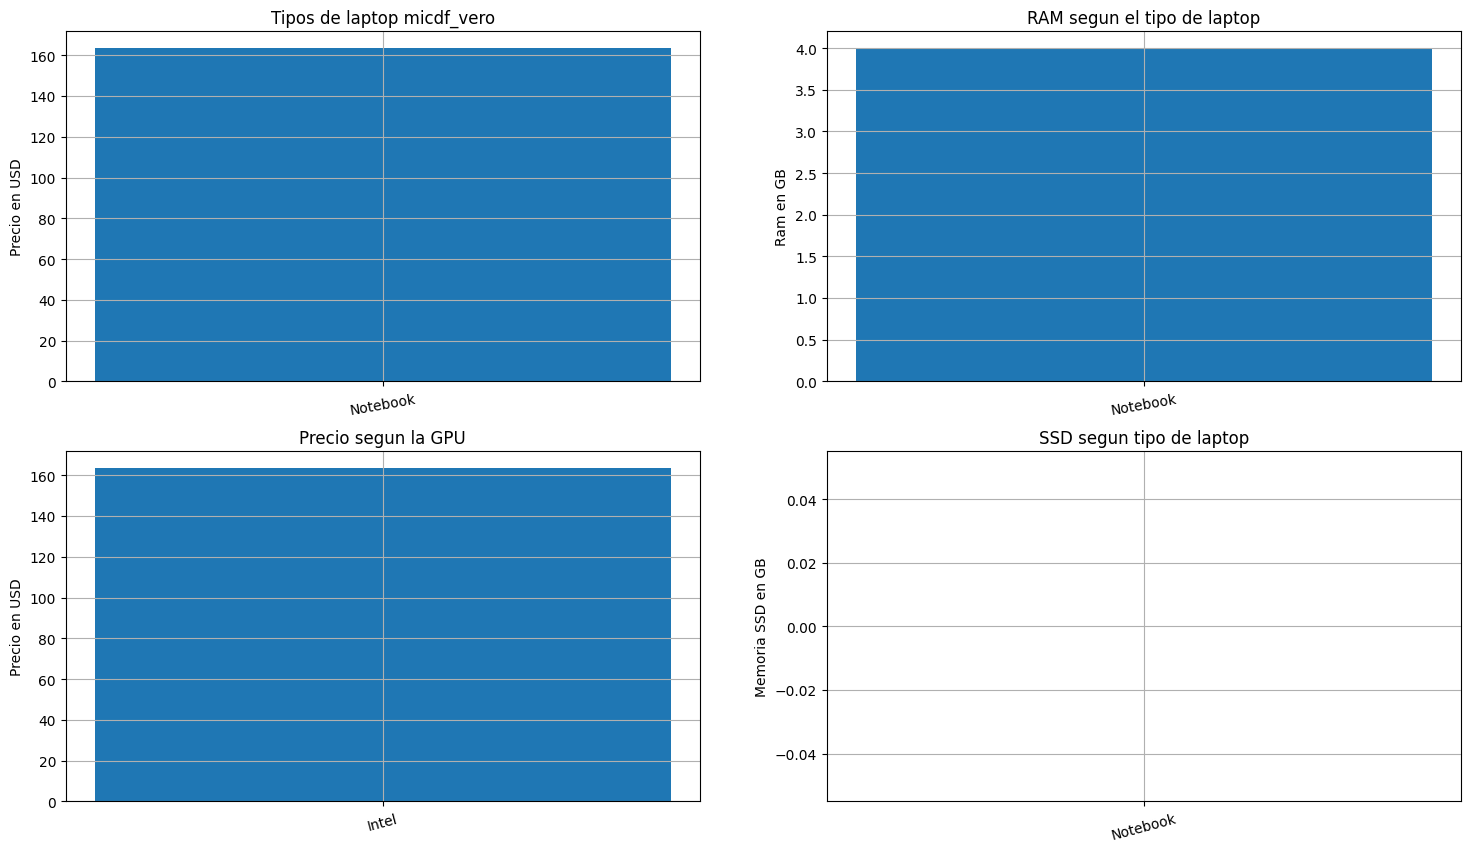

In [285]:
#Usando matplotlib
XTN = df_vero["TypeName"]
YP = df_vero["Price"]
YRAM = df_vero["Ram"]
XGPU = df_vero["Gpu brand"]
XMEM = df_vero["SSD"]


fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(18, 10))

#Tipo de laptop/Precio
axs[0,0].bar(XTN, YP)
axs[0,0].set_title("Tipos de laptop micdf_vero")
axs[0,0].set_xticklabels(set(df_vero["TypeName"]), rotation=10)
axs[0,0].set_ylabel("Precio en USD")
axs[0,0].grid(True)

#Tipo de laptop/RAM
axs[0,1].bar(XTN, YRAM)
axs[0,1].set_title("RAM segun el tipo de laptop")
axs[0,1].set_xticklabels(set(df_vero["TypeName"]), rotation=10)
axs[0,1].set_ylabel("Ram en GB")
axs[0,1].grid(True)


#Tipo de laptop/Gpu brand
axs[1,0].bar(XGPU, YP)
axs[1,0].set_title("Precio segun la GPU")
axs[1,0].set_xticklabels(set(df_vero["Gpu brand"]), rotation=15)
axs[1,0].set_ylabel("Precio en USD")
axs[1,0].grid(True)

#Tipo de memoria/precio
axs[1,1].bar(XTN, XMEM)
axs[1,1].set_title("SSD segun tipo de laptop")
axs[1,1].set_xticklabels(set(df_vero["TypeName"]), rotation=15)
axs[1,1].set_ylabel("Memoria SSD en GB")
axs[1,1].grid(True)

### XIAOMI

In [197]:
df_xiaomi.sort_values("Price", ascending=False)

,Company,TypeName,Ram,Price,Touchscreen,Ips,ppi,Cpu brand,HDD,SSD,Hybrid,Flash_Storage,Gpu brand,os
499,Xiaomi,Notebook,16,880.340638,0,1,141.211998,Intel Core i7,0,256,0,0,Nvidia,Others/No OS/Linux
178,Xiaomi,Notebook,8,753.975803,0,1,141.211998,Intel Core i5,0,256,0,0,Nvidia,Others/No OS/Linux
185,Xiaomi,Ultrabook,8,628.774316,0,1,165.632118,Intel Core i5,0,256,0,0,Nvidia,Others/No OS/Linux
851,Xiaomi,Ultrabook,8,587.962782,0,1,165.632118,Intel Core i5,0,256,0,0,Nvidia,Windows


C:\Users\USUARIO\AppData\Local\Temp\ipykernel_29648\1374794789.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[0,0].set_xticklabels(set(df_xiaomi["TypeName"]), rotation=10)
C:\Users\USUARIO\AppData\Local\Temp\ipykernel_29648\1374794789.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[0,1].set_xticklabels(set(df_xiaomi["TypeName"]), rotation=10)
C:\Users\USUARIO\AppData\Local\Temp\ipykernel_29648\1374794789.py:29: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[1,0].set_xticklabels(set(df_xiaomi["Gpu brand"]), rotation=15)
C:\Users\USUARIO\AppData\Local\Temp\ipykernel_29648\1374794789.py:36: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  a

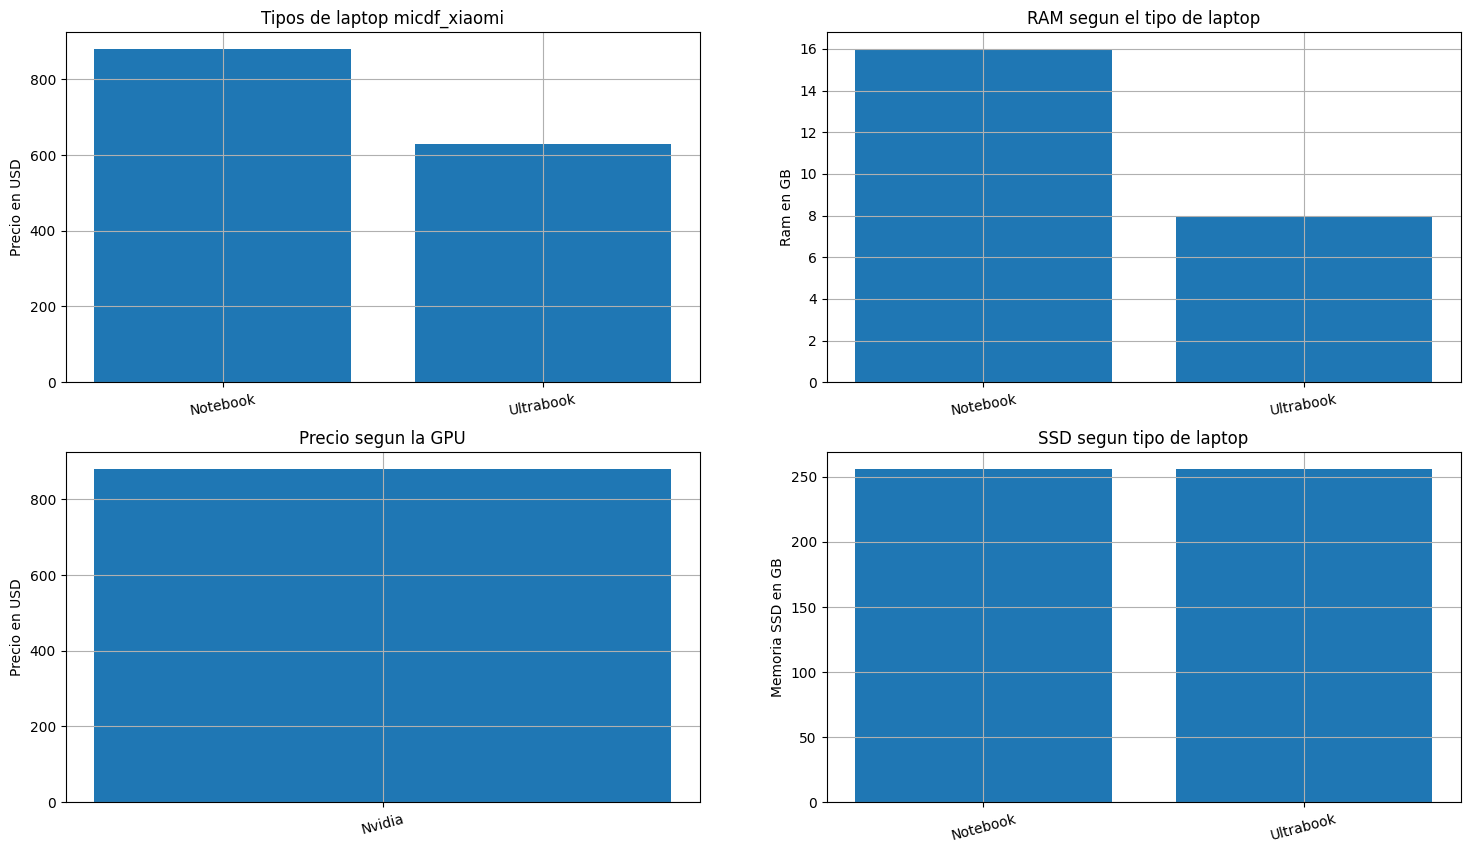

In [286]:
#Usando matplotlib
XTN = df_xiaomi["TypeName"]
YP = df_xiaomi["Price"]
YRAM = df_xiaomi["Ram"]
XGPU = df_xiaomi["Gpu brand"]
XMEM = df_xiaomi["SSD"]


fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(18, 10))

#Tipo de laptop/Precio
axs[0,0].bar(XTN, YP)
axs[0,0].set_title("Tipos de laptop micdf_xiaomi")
axs[0,0].set_xticklabels(set(df_xiaomi["TypeName"]), rotation=10)
axs[0,0].set_ylabel("Precio en USD")
axs[0,0].grid(True)

#Tipo de laptop/RAM
axs[0,1].bar(XTN, YRAM)
axs[0,1].set_title("RAM segun el tipo de laptop")
axs[0,1].set_xticklabels(set(df_xiaomi["TypeName"]), rotation=10)
axs[0,1].set_ylabel("Ram en GB")
axs[0,1].grid(True)


#Tipo de laptop/Gpu brand
axs[1,0].bar(XGPU, YP)
axs[1,0].set_title("Precio segun la GPU")
axs[1,0].set_xticklabels(set(df_xiaomi["Gpu brand"]), rotation=15)
axs[1,0].set_ylabel("Precio en USD")
axs[1,0].grid(True)

#Tipo de memoria/precio
axs[1,1].bar(XTN, XMEM)
axs[1,1].set_title("SSD segun tipo de laptop")
axs[1,1].set_xticklabels(set(df_xiaomi["TypeName"]), rotation=15)
axs[1,1].set_ylabel("Memoria SSD en GB")
axs[1,1].grid(True)

### CHUWI

In [198]:
df_chuwi.sort_values("Price", ascending=False)

,Company,TypeName,Ram,Price,Touchscreen,Ips,ppi,Cpu brand,HDD,SSD,Hybrid,Flash_Storage,Gpu brand,os
408,Chuwi,Notebook,6,282.347903,0,1,267.338436,Other Intel Processor,0,0,0,64,Intel,Windows
468,Chuwi,Notebook,4,156.517579,0,0,141.211998,Other Intel Processor,0,0,0,64,Intel,Windows
29,Chuwi,Notebook,4,154.058826,0,0,141.211998,Other Intel Processor,0,0,0,64,Intel,Windows


C:\Users\USUARIO\AppData\Local\Temp\ipykernel_29648\1445241244.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[0,0].set_xticklabels(set(df_chuwi["TypeName"]), rotation=10)
C:\Users\USUARIO\AppData\Local\Temp\ipykernel_29648\1445241244.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[0,1].set_xticklabels(set(df_chuwi["TypeName"]), rotation=10)
C:\Users\USUARIO\AppData\Local\Temp\ipykernel_29648\1445241244.py:29: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[1,0].set_xticklabels(set(df_chuwi["Gpu brand"]), rotation=15)
C:\Users\USUARIO\AppData\Local\Temp\ipykernel_29648\1445241244.py:36: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[

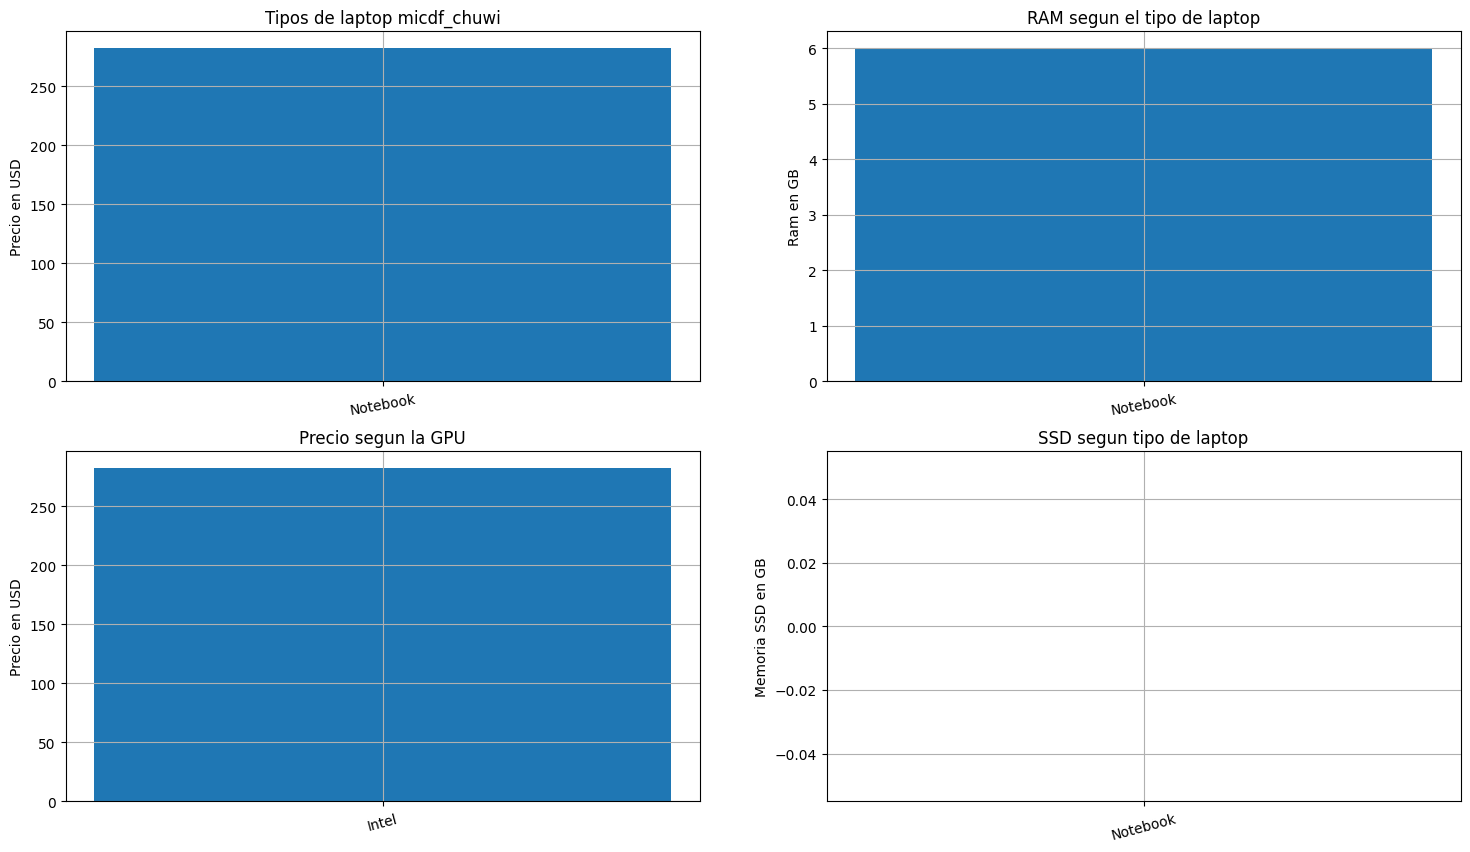

In [288]:
#Usando matplotlib
XTN = df_chuwi["TypeName"]
YP = df_chuwi["Price"]
YRAM = df_chuwi["Ram"]
XGPU = df_chuwi["Gpu brand"]
XMEM = df_chuwi["SSD"]


fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(18, 10))

#Tipo de laptop/Precio
axs[0,0].bar(XTN, YP)
axs[0,0].set_title("Tipos de laptop micdf_chuwi")
axs[0,0].set_xticklabels(set(df_chuwi["TypeName"]), rotation=10)
axs[0,0].set_ylabel("Precio en USD")
axs[0,0].grid(True)

#Tipo de laptop/RAM
axs[0,1].bar(XTN, YRAM)
axs[0,1].set_title("RAM segun el tipo de laptop")
axs[0,1].set_xticklabels(set(df_chuwi["TypeName"]), rotation=10)
axs[0,1].set_ylabel("Ram en GB")
axs[0,1].grid(True)


#Tipo de laptop/Gpu brand
axs[1,0].bar(XGPU, YP)
axs[1,0].set_title("Precio segun la GPU")
axs[1,0].set_xticklabels(set(df_chuwi["Gpu brand"]), rotation=15)
axs[1,0].set_ylabel("Precio en USD")
axs[1,0].grid(True)

#Tipo de memoria/precio
axs[1,1].bar(XTN, XMEM)
axs[1,1].set_title("SSD segun tipo de laptop")
axs[1,1].set_xticklabels(set(df_chuwi["TypeName"]), rotation=15)
axs[1,1].set_ylabel("Memoria SSD en GB")
axs[1,1].grid(True)

In [199]:
df_lg.sort_values("Price", ascending=False)

,Company,TypeName,Ram,Price,Touchscreen,Ips,ppi,Cpu brand,HDD,SSD,Hybrid,Flash_Storage,Gpu brand,os
658,LG,Ultrabook,8,1445.696723,0,1,141.211998,Intel Core i7,0,512,0,0,Intel,Windows
879,LG,Ultrabook,16,1319.929283,1,1,141.211998,Intel Core i7,0,512,0,0,Intel,Windows
883,LG,Ultrabook,8,1194.161843,1,1,157.350512,Intel Core i7,0,512,0,0,Intel,Windows


### GOOGLE

C:\Users\USUARIO\AppData\Local\Temp\ipykernel_29648\2744353000.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[0,0].set_xticklabels(set(df_lg["TypeName"]), rotation=10)
C:\Users\USUARIO\AppData\Local\Temp\ipykernel_29648\2744353000.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[0,1].set_xticklabels(set(df_lg["TypeName"]), rotation=10)
C:\Users\USUARIO\AppData\Local\Temp\ipykernel_29648\2744353000.py:29: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[1,0].set_xticklabels(set(df_lg["Gpu brand"]), rotation=15)
C:\Users\USUARIO\AppData\Local\Temp\ipykernel_29648\2744353000.py:36: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[1,1].set_

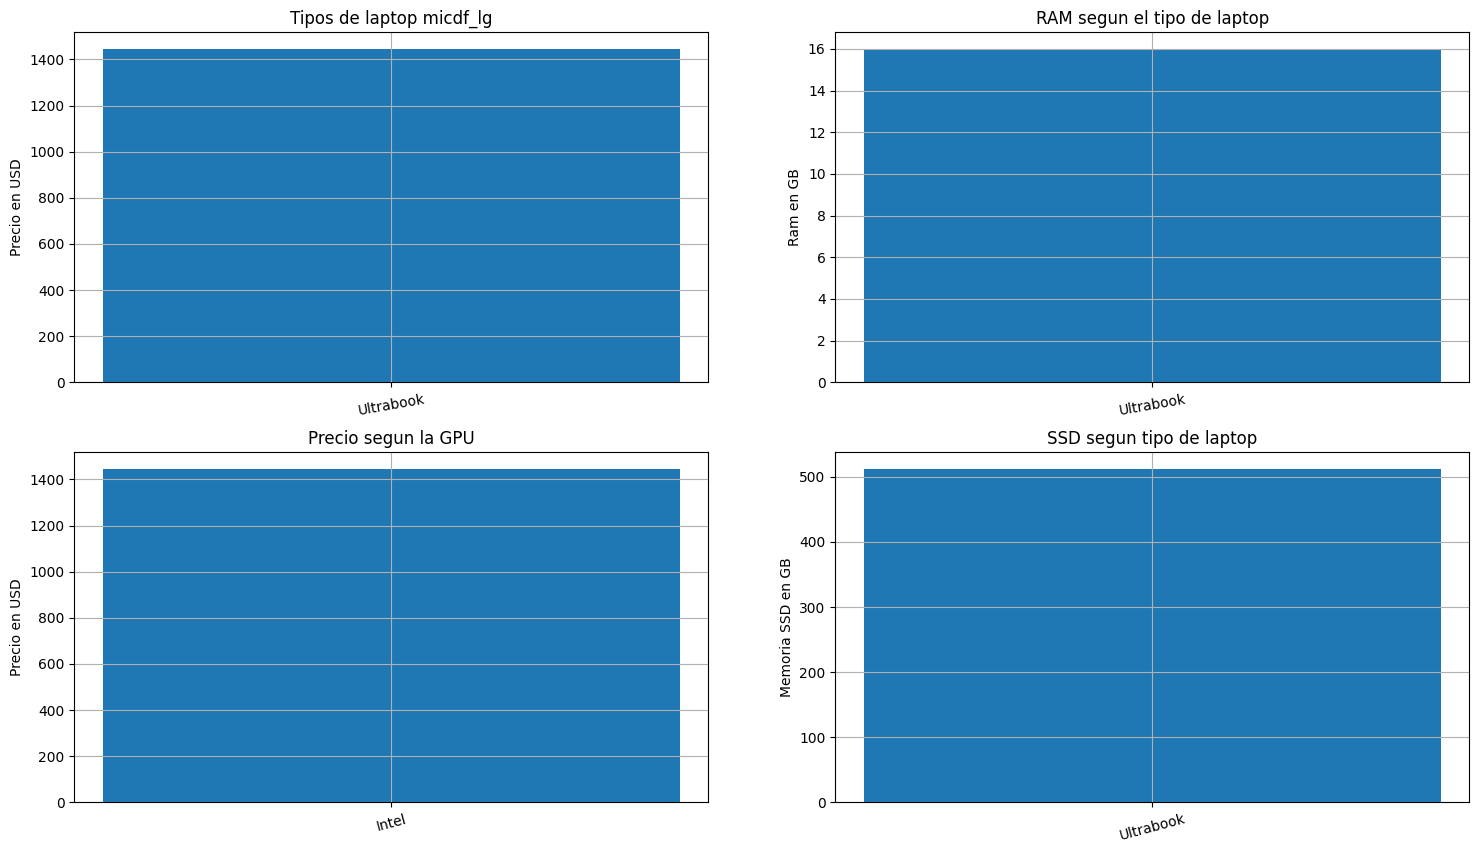

In [289]:
#Usando matplotlib
XTN = df_lg["TypeName"]
YP = df_lg["Price"]
YRAM = df_lg["Ram"]
XGPU = df_lg["Gpu brand"]
XMEM = df_lg["SSD"]


fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(18, 10))

#Tipo de laptop/Precio
axs[0,0].bar(XTN, YP)
axs[0,0].set_title("Tipos de laptop micdf_lg")
axs[0,0].set_xticklabels(set(df_lg["TypeName"]), rotation=10)
axs[0,0].set_ylabel("Precio en USD")
axs[0,0].grid(True)

#Tipo de laptop/RAM
axs[0,1].bar(XTN, YRAM)
axs[0,1].set_title("RAM segun el tipo de laptop")
axs[0,1].set_xticklabels(set(df_lg["TypeName"]), rotation=10)
axs[0,1].set_ylabel("Ram en GB")
axs[0,1].grid(True)


#Tipo de laptop/Gpu brand
axs[1,0].bar(XGPU, YP)
axs[1,0].set_title("Precio segun la GPU")
axs[1,0].set_xticklabels(set(df_lg["Gpu brand"]), rotation=15)
axs[1,0].set_ylabel("Precio en USD")
axs[1,0].grid(True)

#Tipo de memoria/precio
axs[1,1].bar(XTN, XMEM)
axs[1,1].set_title("SSD segun tipo de laptop")
axs[1,1].set_xticklabels(set(df_lg["TypeName"]), rotation=15)
axs[1,1].set_ylabel("Memoria SSD en GB")
axs[1,1].grid(True)

In [200]:
df_google.sort_values("Price", ascending=False)

,Company,TypeName,Ram,Price,Touchscreen,Ips,ppi,Cpu brand,HDD,SSD,Hybrid,Flash_Storage,Gpu brand,os
424,Google,Ultrabook,16,1382.813003,1,0,234.5074,Intel Core i7,0,512,0,0,Intel,Others/No OS/Linux
738,Google,Ultrabook,8,980.357195,1,0,234.5074,Intel Core i5,0,256,0,0,Intel,Others/No OS/Linux
459,Google,Ultrabook,8,801.767430,1,0,234.5074,Intel Core i5,0,128,0,0,Intel,Others/No OS/Linux


### HUAWEI

In [201]:
df_huawei.sort_values("Price", ascending=False)

,Company,TypeName,Ram,Price,Touchscreen,Ips,ppi,Cpu brand,HDD,SSD,Hybrid,Flash_Storage,Gpu brand,os
205,Huawei,Ultrabook,8,942.626963,0,1,199.692071,Intel Core i7,0,512,0,0,Intel,Windows
164,Huawei,Ultrabook,8,848.301383,0,1,199.692071,Intel Core i5,0,256,0,0,Intel,Windows


### FUJITSU

In [202]:
df_fujitsu.sort_values("Price", ascending=False)

,Company,TypeName,Ram,Price,Touchscreen,Ips,ppi,Cpu brand,HDD,SSD,Hybrid,Flash_Storage,Gpu brand,os
606,Fujitsu,Notebook,8,502.440923,0,0,100.45467,Intel Core i5,0,256,0,0,Intel,Windows
953,Fujitsu,Notebook,4,408.115343,0,0,100.45467,Intel Core i5,0,256,0,0,Intel,Windows


## Filtrado segun la Capacidad de procesamiento

In [203]:
#Datos realacionados a la capacidad/Potencia de procesamiento
df_software = df[["Company", "TypeName", "Ram", "HDD", "SSD", "Hybrid", "Flash_Storage", "Cpu brand", "os", "Price"]]
df_software

,Company,TypeName,Ram,HDD,SSD,Hybrid,Flash_Storage,Cpu brand,os,Price
0,Apple,Ultrabook,8,0,128,0,0,Intel Core i5,Mac,842.446908
1,Apple,Ultrabook,8,0,0,0,128,Intel Core i5,Mac,565.286913
2,HP,Notebook,8,0,256,0,0,Intel Core i5,Others/No OS/Linux,361.581390
3,Apple,Ultrabook,16,0,512,0,0,Intel Core i7,Mac,1595.642953
4,Apple,Ultrabook,8,0,256,0,0,Intel Core i5,Mac,1134.170774
...,...,...,...,...,...,...,...,...,...,...
1263,Lenovo,2 in 1 Convertible,4,0,128,0,0,Intel Core i7,Windows,401.198134
1264,Lenovo,2 in 1 Convertible,16,0,512,0,0,Intel Core i7,Windows,942.626963
1265,Lenovo,Notebook,2,0,0,0,64,Other Intel Processor,Windows,144.003719
1266,HP,Notebook,6,1000,0,0,0,Intel Core i7,Windows,480.431621


In [204]:
df_software.sort_values("Price", ascending=False)

,Company,TypeName,Ram,HDD,SSD,Hybrid,Flash_Storage,Cpu brand,os,Price
189,Razer,Gaming,32,0,1000,0,0,Intel Core i7,Windows,3835.278083
804,Razer,Gaming,32,0,512,0,0,Intel Core i7,Windows,3457.975763
594,Lenovo,Notebook,32,0,1000,0,0,Other Intel Processor,Windows,3080.673443
726,HP,Workstation,16,0,256,0,0,Other Intel Processor,Windows,2759.966471
1034,Asus,Gaming,64,0,1000,0,0,Intel Core i7,Windows,2499.627870
...,...,...,...,...,...,...,...,...,...,...
765,Vero,Notebook,4,0,0,0,32,Other Intel Processor,Windows,127.591068
30,Asus,Notebook,2,0,0,0,32,AMD Processor,Windows,125.138603
280,Acer,Notebook,2,0,16,0,0,Other Intel Processor,Others/No OS/Linux,125.138603
1088,Vero,Notebook,4,0,0,0,32,Other Intel Processor,Windows,123.252091


In [206]:
#Componentes mas potentes
df_bigcapacity = df_software[
    (df_software["Ram"] >= 32) & 
    (df_software["SSD"] >= 512)]

df_middlecapacity = df_software[
    (df_software["Ram"] <= 32) & 
    (df_software["SSD"] < 1000 ) & 
    (df_software["Ram"] > 16)]

df_lowcapacity = df_software[
    (df_software["Ram"] <= 16) &
    (df_software["SSD"] <= 256)]




### Laptop De mas alto procesamiento

In [207]:
df_bigcapacity

,Company,TypeName,Ram,HDD,SSD,Hybrid,Flash_Storage,Cpu brand,os,Price
171,MSI,Gaming,32,1000,512,0,0,Intel Core i7,Windows,1760.115323
189,Razer,Gaming,32,0,1000,0,0,Intel Core i7,Windows,3835.278083
229,Asus,Gaming,32,1000,512,0,0,Intel Core i7,Windows,2446.176708
319,Dell,Notebook,32,0,1000,0,0,Intel Core i7,Windows,1659.501371
476,Toshiba,Ultrabook,32,0,512,0,0,Intel Core i7,Windows,1760.115323
594,Lenovo,Notebook,32,0,1000,0,0,Other Intel Processor,Windows,3080.673443
631,Asus,Gaming,32,0,512,0,0,Intel Core i7,Windows,1760.115323
640,Dell,Gaming,32,1000,512,0,0,Intel Core i7,Windows,1979.183338
699,Lenovo,Ultrabook,64,0,512,0,0,Intel Core i7,Windows,1060.621975
702,Dell,Gaming,32,1000,1000,0,0,Intel Core i7,Windows,2301.166850


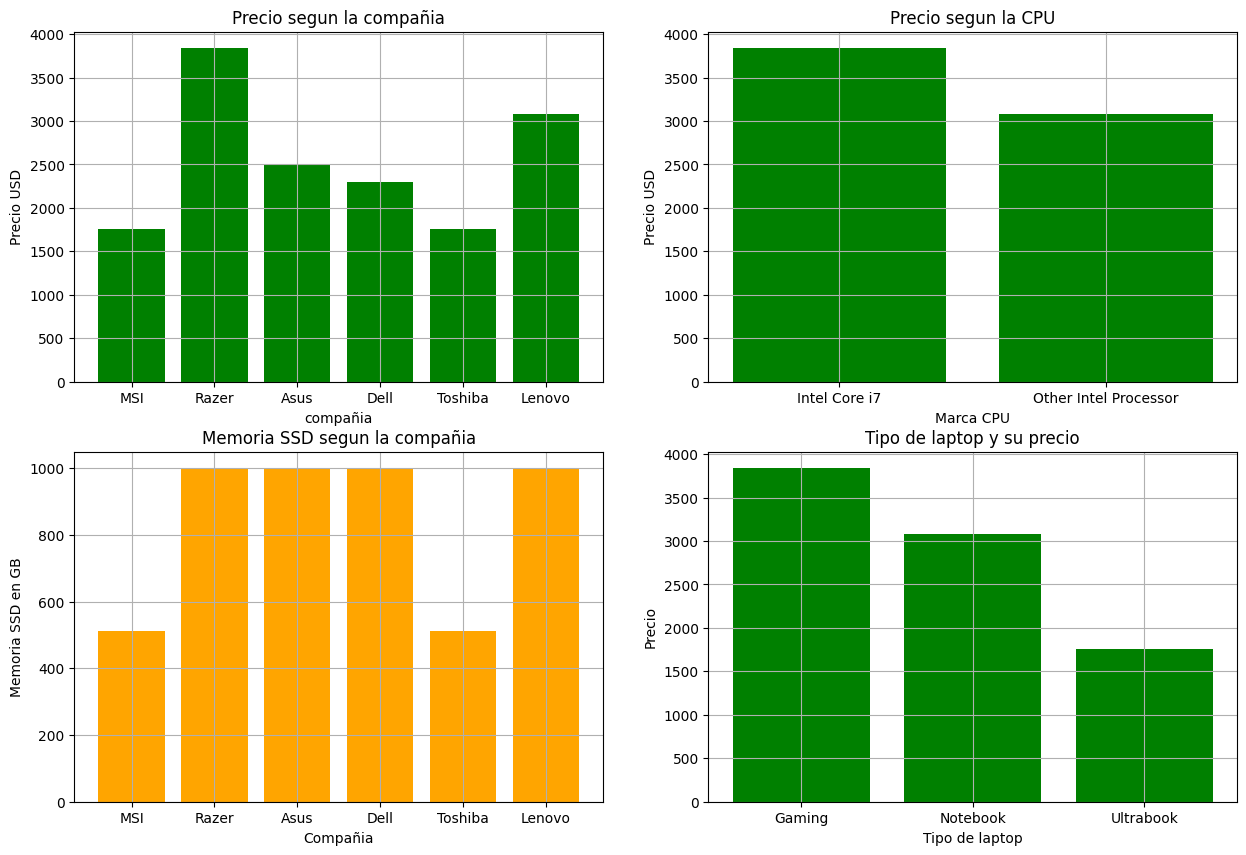

In [208]:
#Matplotlib: Relacion con respecto al PRECIO

fig, axs = plt.subplots(
    figsize = (15, 10), nrows=2, ncols=2
)
XC = df_bigcapacity["Company"] #Compañia
YP = df_bigcapacity["Price"] #Precio laptop
XCPU = df_bigcapacity["Cpu brand"] #Marca de la cpu
YSSD = df_bigcapacity["SSD"] # Cantidad de SSD en gb
XTYPE = df_bigcapacity["TypeName"]


#Grafico 0,0 company/price
axs[0,0].bar(XC,YP, color="green")
axs[0,0].set_title("Precio segun la compañia")
axs[0,0].set_xlabel("compañia")
axs[0,0].set_ylabel("Precio USD")
axs[0,0].grid(True)


#Grafico 0,1 cpu brand/price
axs[0,1].bar(XCPU, YP, color="green")
axs[0,1].set_title("Precio segun la CPU")
axs[0,1].set_xlabel("Marca CPU")
axs[0,1].set_ylabel("Precio USD")
axs[0,1].grid(True)

#Grafico 1,0 company/SSD en gb
axs[1,0].bar(XC, YSSD, color = "orange")
axs[1,0].set_title("Memoria SSD segun la compañia")
axs[1,0].set_xlabel("Compañia")
axs[1,0].set_ylabel("Memoria SSD en GB")
axs[1,0].grid(True)

#Grafico 1,1 TypeName/Price
axs[1,1].bar(XTYPE, YP, color="green")
axs[1,1].set_title("Tipo de laptop y su precio")
axs[1,1].set_xlabel("Tipo de laptop")
axs[1,1].set_ylabel("Precio")
axs[1,1].grid(True)

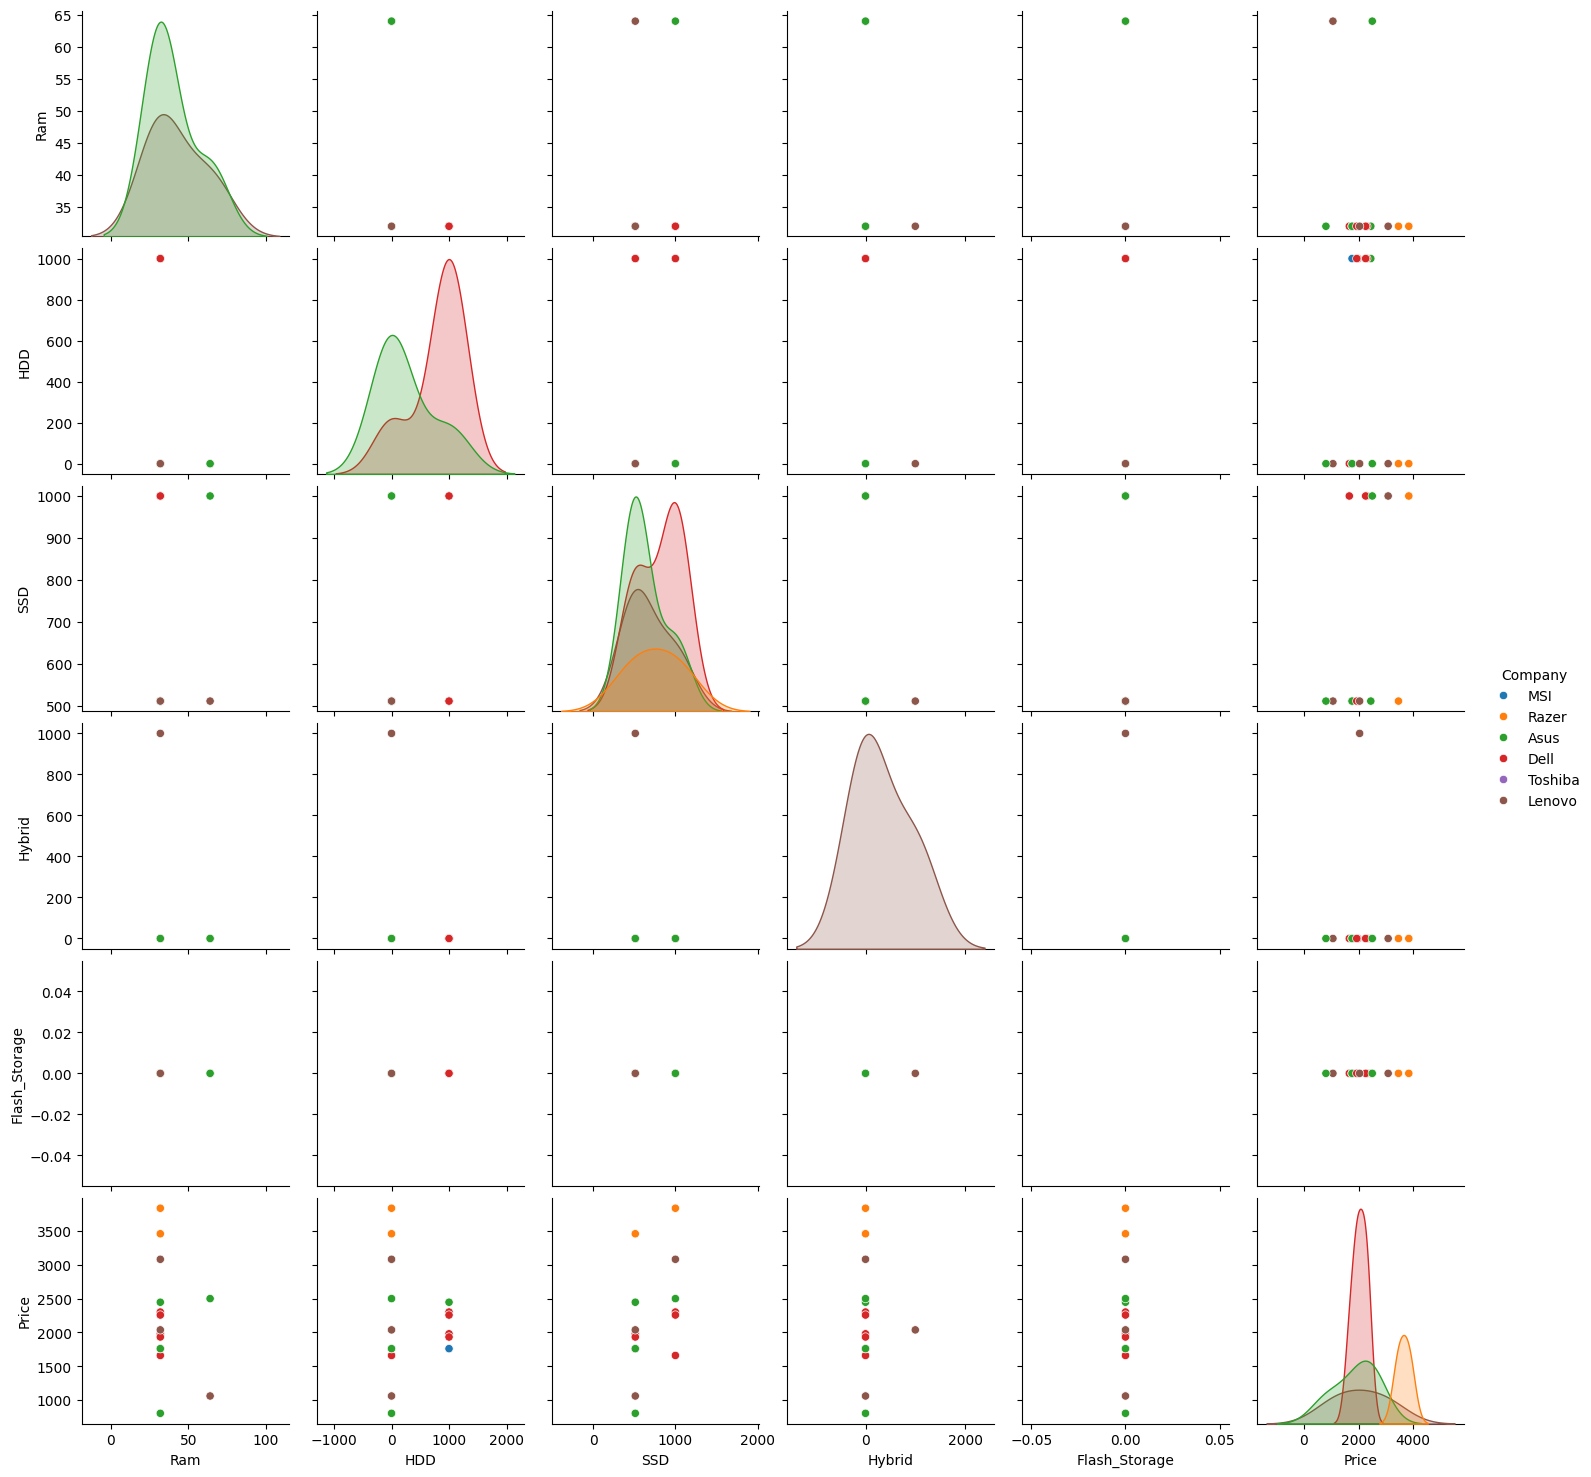

In [209]:
#Seaborn: Relacion con respecto a la capacidad de procesamiento

sns.pairplot(df_bigcapacity, hue="Company")

### Laptops de mediano procesamiento


In [210]:
df_middlecapacity.sort_values("Ram", ascending=False)

,Company,TypeName,Ram,HDD,SSD,Hybrid,Flash_Storage,Cpu brand,os,Price
171,MSI,Gaming,32,1000,512,0,0,Intel Core i7,Windows,1760.115323
229,Asus,Gaming,32,1000,512,0,0,Intel Core i7,Windows,2446.176708
476,Toshiba,Ultrabook,32,0,512,0,0,Intel Core i7,Windows,1760.115323
561,Lenovo,Gaming,32,1000,256,0,0,Intel Core i7,Windows,1674.593464
804,Razer,Gaming,32,0,512,0,0,Intel Core i7,Windows,3457.975763
640,Dell,Gaming,32,1000,512,0,0,Intel Core i7,Windows,1979.183338
631,Asus,Gaming,32,0,512,0,0,Intel Core i7,Windows,1760.115323
875,Asus,Gaming,32,0,512,0,0,Intel Core i7,Windows,804.282779
939,Dell,Gaming,32,1000,256,0,0,Intel Core i7,Windows,1980.208343
943,Dell,Gaming,32,1000,256,0,0,Intel Core i7,Windows,1760.744160


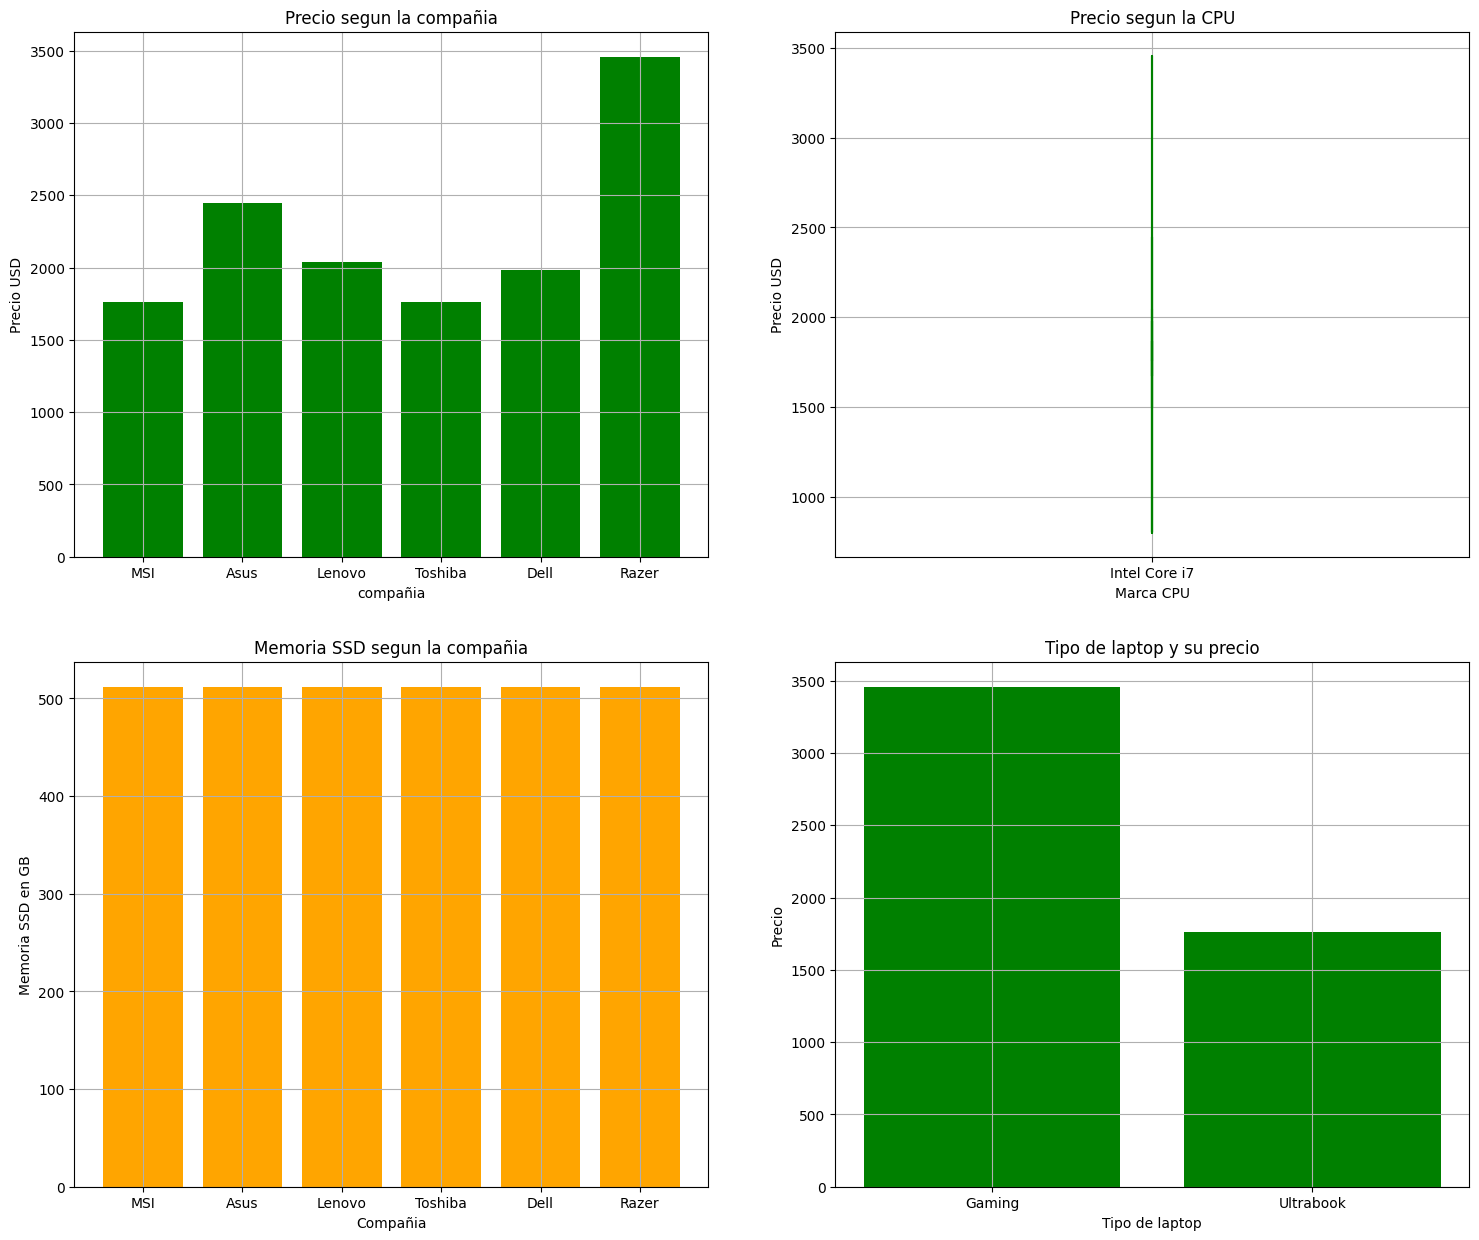

In [211]:
fig, axs = plt.subplots(
    figsize = (18, 15), nrows=2, ncols=2
)

XC = df_middlecapacity["Company"] #Compañia
YP = df_middlecapacity["Price"] #Precio laptop
XCPU = df_middlecapacity["Cpu brand"] #Marca de la cpu
YSSD = df_middlecapacity["SSD"] # Cantidad de SSD en gb
XTYPE = df_middlecapacity["TypeName"] #Tipo de laptop


#Grafico 0,0 company/price
axs[0,0].bar(XC,YP, color="green")
axs[0,0].set_title("Precio segun la compañia")
axs[0,0].set_xlabel("compañia")
axs[0,0].set_ylabel("Precio USD")
axs[0,0].grid(True)


#Grafico 0,1 cpu brand/price
axs[0,1].plot(XCPU, YP, color="green")
axs[0,1].set_title("Precio segun la CPU")
axs[0,1].set_xlabel("Marca CPU")
axs[0,1].set_ylabel("Precio USD")
axs[0,1].grid(True)

#Grafico 1,0 company/SSD en gb
axs[1,0].bar(XC, YSSD, color = "orange")
axs[1,0].set_title("Memoria SSD segun la compañia")
axs[1,0].set_xlabel("Compañia")
axs[1,0].set_ylabel("Memoria SSD en GB")
axs[1,0].grid(True)

#Grafico 1,1 TypeName/Price
axs[1,1].bar(XTYPE, YP, color="green")
axs[1,1].set_title("Tipo de laptop y su precio")
axs[1,1].set_xlabel("Tipo de laptop")
axs[1,1].set_ylabel("Precio")
axs[1,1].grid(True)



<Figure size 2000x1500 with 0 Axes>

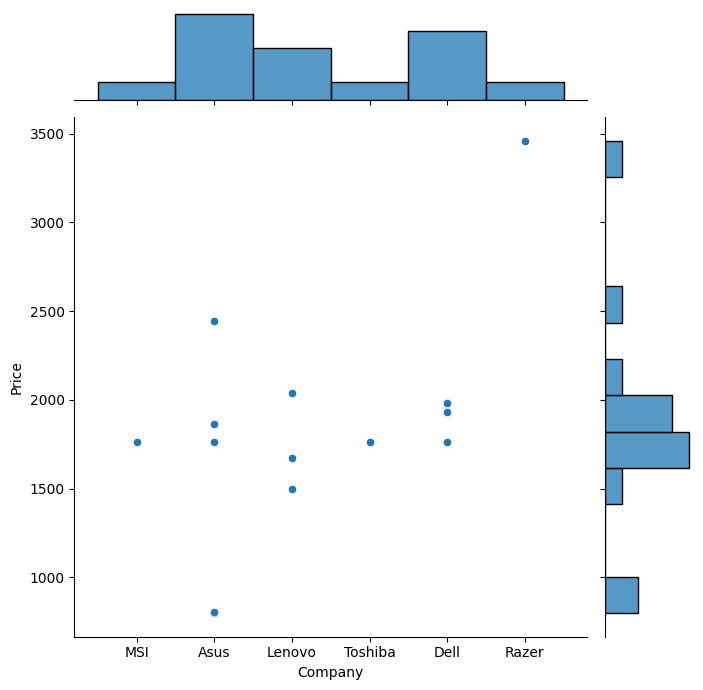

In [212]:
plt.figure(figsize=(20, 15))
sns.jointplot(y=df_middlecapacity["Price"], x=df_middlecapacity["Company"],
              height=7)

### Laptops de bajo procesamiento

In [213]:
df_lowcapacity

,Company,TypeName,Ram,HDD,SSD,Hybrid,Flash_Storage,Cpu brand,os,Price
0,Apple,Ultrabook,8,0,128,0,0,Intel Core i5,Mac,842.446908
1,Apple,Ultrabook,8,0,0,0,128,Intel Core i5,Mac,565.286913
2,HP,Notebook,8,0,256,0,0,Intel Core i5,Others/No OS/Linux,361.581390
4,Apple,Ultrabook,8,0,256,0,0,Intel Core i5,Mac,1134.170774
5,Acer,Notebook,4,500,0,0,0,AMD Processor,Windows,251.534880
...,...,...,...,...,...,...,...,...,...,...
1262,Asus,Notebook,4,500,0,0,0,Intel Core i7,Windows,452.964012
1263,Lenovo,2 in 1 Convertible,4,0,128,0,0,Intel Core i7,Windows,401.198134
1265,Lenovo,Notebook,2,0,0,0,64,Other Intel Processor,Windows,144.003719
1266,HP,Notebook,6,1000,0,0,0,Intel Core i7,Windows,480.431621


Text(0, 0.5, 'HDD')

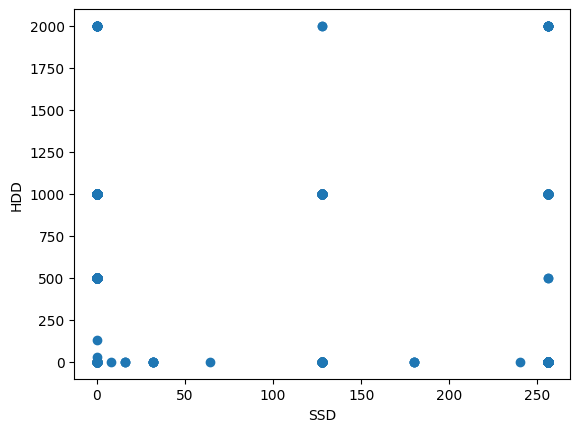

In [214]:
#Matplotlib
x = df_lowcapacity["SSD"]
y = df_lowcapacity["HDD"]
fig, ax=plt.subplots()
ax.scatter(x,y)
plt.xlabel("SSD")
plt.ylabel("HDD")

## Filtrado de compañias segun su precio

In [215]:
Big_price = df[df["Price"] >= 2000]  
middle_price = df[(df["Price"] < 2000) & (df["Price"] >= 1000) ]
cheap_price = df[(df["Price"] < 1000) & (df["Price"] > 500)]
most_cheap_price = df[df["Price"] <= 500]

### Laptops Mas caras $2000 o mas

In [216]:
Big_price.sort_values("Price", ascending=False)


,Company,TypeName,Ram,Price,Touchscreen,Ips,ppi,Cpu brand,HDD,SSD,Hybrid,Flash_Storage,Gpu brand,os
189,Razer,Gaming,32,3835.278083,1,0,254.671349,Intel Core i7,0,1000,0,0,Nvidia,Windows
804,Razer,Gaming,32,3457.975763,1,0,254.671349,Intel Core i7,0,512,0,0,Nvidia,Windows
594,Lenovo,Notebook,32,3080.673443,0,1,282.423996,Other Intel Processor,0,1000,0,0,Nvidia,Windows
726,HP,Workstation,16,2759.966471,0,1,127.335675,Other Intel Processor,0,256,0,0,Nvidia,Windows
1034,Asus,Gaming,64,2499.627870,0,1,127.335675,Intel Core i7,0,1000,0,0,Nvidia,Windows
1104,HP,Workstation,8,2483.529638,0,1,127.335675,Intel Core i7,0,256,0,0,Nvidia,Windows
229,Asus,Gaming,32,2446.176708,0,0,127.335675,Intel Core i7,1000,512,0,0,Nvidia,Windows
702,Dell,Gaming,32,2301.166850,0,0,254.671349,Intel Core i7,1000,1000,0,0,Nvidia,Windows
754,Dell,Gaming,32,2256.770943,0,1,127.335675,Intel Core i7,1000,1000,0,0,Nvidia,Windows
1197,Razer,Gaming,16,2200.301363,0,0,157.350512,Intel Core i7,0,1000,0,0,Nvidia,Windows


Text(0, 0.5, 'Price')

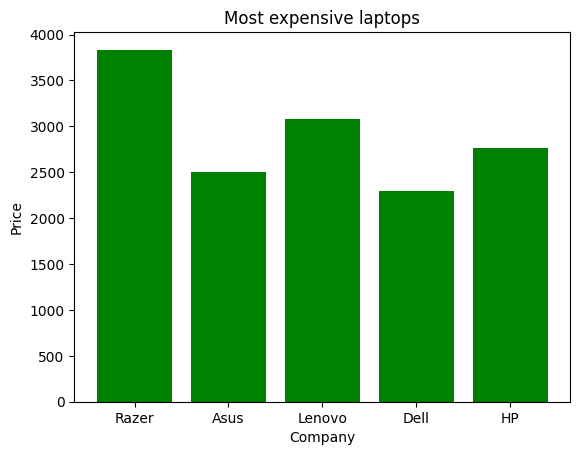

In [217]:
x = Big_price["Company"]
y = Big_price["Price"]
plt.bar(x, y, color='g')
plt.title("Most expensive laptops")
plt.xlabel("Company")
plt.ylabel("Price")


### Laptops de precio medio entre $2000 y $1000

In [218]:
middle_price.sort_values("Price", ascending=False)


,Company,TypeName,Ram,Price,Touchscreen,Ips,ppi,Cpu brand,HDD,SSD,Hybrid,Flash_Storage,Gpu brand,os
926,Dell,Gaming,16,1983.352529,0,1,254.671349,Intel Core i7,1000,512,0,0,Nvidia,Windows
939,Dell,Gaming,32,1980.208343,0,1,127.335675,Intel Core i7,1000,256,0,0,Nvidia,Windows
640,Dell,Gaming,32,1979.183338,0,1,254.671349,Intel Core i7,1000,512,0,0,Nvidia,Windows
885,HP,Ultrabook,8,1949.395320,1,0,352.465147,Other Intel Processor,0,240,0,0,Intel,Windows
815,Dell,Gaming,32,1932.347544,0,1,127.335675,Intel Core i7,1000,512,0,0,Nvidia,Windows
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
744,Samsung,Ultrabook,8,1005.510683,1,0,165.632118,Intel Core i7,0,256,0,0,Intel,Windows
1060,Asus,Gaming,8,1005.510683,0,1,127.335675,Intel Core i7,1000,256,0,0,Nvidia,Windows
891,MSI,Gaming,16,1005.510683,0,0,127.335675,Intel Core i7,1000,256,0,0,Nvidia,Windows
1199,MSI,Gaming,16,1004.881846,0,0,127.335675,Intel Core i7,1000,256,0,0,Nvidia,Windows


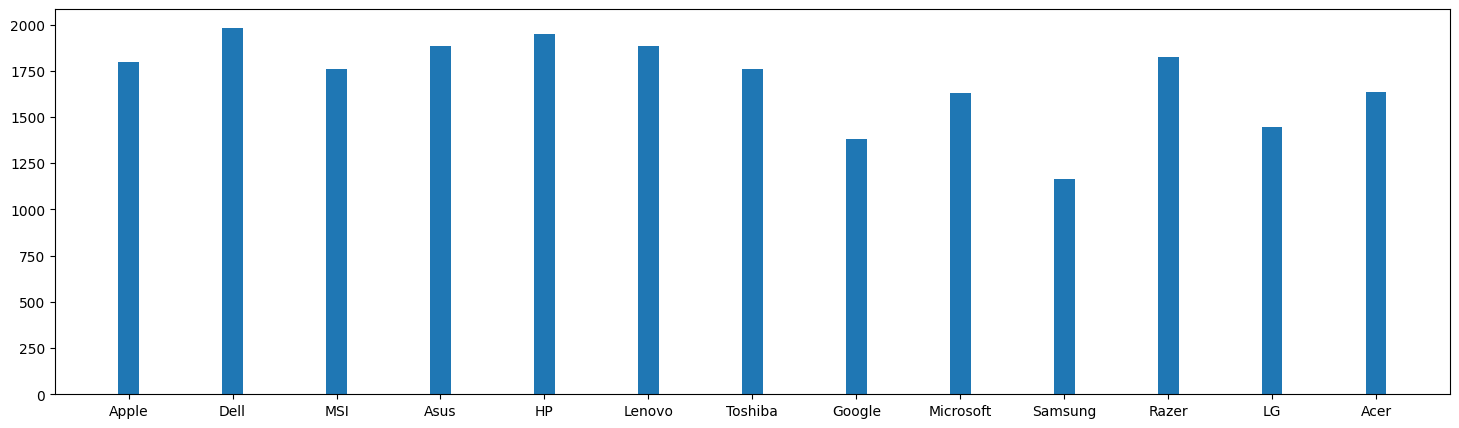

In [290]:
x = middle_price["Company"]
y = middle_price["Price"]

fig, ax = plt.subplots(
    figsize=(18,5)
)
ax = plt.bar(x,y, width=0.2, )

### Laptops de bajo precio entre $1000 y $500

In [220]:
cheap_price.sort_values("Price", ascending=False)

,Company,TypeName,Ram,Price,Touchscreen,Ips,ppi,Cpu brand,HDD,SSD,Hybrid,Flash_Storage,Gpu brand,os
981,HP,Notebook,4,999.851148,0,0,157.350512,Intel Core i5,0,256,0,0,Intel,Windows
990,Toshiba,Ultrabook,8,999.851148,0,0,165.632118,Intel Core i5,0,256,0,0,Intel,Windows
630,Lenovo,Ultrabook,8,996.078125,0,1,176.232574,Intel Core i7,0,256,0,0,Intel,Windows
903,HP,Ultrabook,4,992.933939,0,0,176.232574,Intel Core i5,500,0,0,0,Intel,Windows
1116,HP,Notebook,8,992.933939,0,0,141.211998,Intel Core i5,0,256,0,0,Intel,Windows
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
450,Lenovo,Notebook,8,502.440923,0,1,157.350512,Intel Core i7,0,512,0,0,AMD,Others/No OS/Linux
1035,Dell,2 in 1 Convertible,8,501.818374,1,0,165.632118,Intel Core i7,0,256,0,0,Intel,Windows
528,Acer,Gaming,8,501.812086,0,0,141.211998,Intel Core i5,1000,0,0,0,Nvidia,Others/No OS/Linux
521,Dell,Notebook,8,501.441072,0,0,141.211998,Intel Core i5,0,256,0,0,AMD,Windows


In [221]:
cheap_price["Company"].value_counts()

Company
Dell         130
HP           109
Lenovo       109
Asus          60
Toshiba       30
MSI           25
Acer          21
Apple         14
Xiaomi         4
Microsoft      3
Huawei         2
Google         2
Fujitsu        1
Samsung        1
Razer          1
Name: count, dtype: int64

In [222]:
cheap_price_RAM8 = cheap_price[(cheap_price["Ram"] == 8)]
cheap_price_RAM4 = cheap_price[(cheap_price["Ram"] == 4)]
cheap_price_RAM2 = cheap_price[(cheap_price["Ram"] == 2)]

In [223]:
cheap_price_RAM8 


,Company,TypeName,Ram,Price,Touchscreen,Ips,ppi,Cpu brand,HDD,SSD,Hybrid,Flash_Storage,Gpu brand,os
0,Apple,Ultrabook,8,842.446908,0,1,226.983005,Intel Core i5,0,128,0,0,Intel,Mac
1,Apple,Ultrabook,8,565.286913,0,0,127.677940,Intel Core i5,0,0,0,128,Intel,Mac
7,Apple,Ultrabook,8,728.633664,0,0,127.677940,Intel Core i5,0,0,0,256,Intel,Mac
14,Apple,Ultrabook,8,793.844081,0,1,226.415547,Other Intel Processor,0,256,0,0,Intel,Mac
15,Apple,Ultrabook,8,954.920730,0,1,226.983005,Intel Core i5,0,256,0,0,Intel,Mac
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1232,Dell,Notebook,8,506.836495,0,0,100.454670,Intel Core i7,1000,0,0,0,AMD,Others/No OS/Linux
1244,Lenovo,Notebook,8,565.324643,0,1,141.211998,Intel Core i7,1000,0,0,0,Nvidia,Windows
1246,Dell,Notebook,8,506.836495,0,0,100.454670,Intel Core i7,1000,0,0,0,AMD,Others/No OS/Linux
1258,Lenovo,Notebook,8,565.324643,0,1,141.211998,Intel Core i7,1000,0,0,0,Nvidia,Windows


In [224]:
cheap_price_RAM4


,Company,TypeName,Ram,Price,Touchscreen,Ips,ppi,Cpu brand,HDD,SSD,Hybrid,Flash_Storage,Gpu brand,os
67,Microsoft,Ultrabook,4,684.803711,1,0,200.842560,Intel Core i5,0,128,0,0,Intel,Windows
148,HP,Ultrabook,4,680.401850,0,0,157.350512,Intel Core i5,0,256,0,0,Intel,Windows
155,Acer,Notebook,4,506.213946,0,1,127.335675,Intel Core i5,0,256,0,0,Nvidia,Windows
444,Microsoft,Ultrabook,4,621.919991,1,0,200.842560,Other Intel Processor,0,128,0,0,Intel,Windows
511,Lenovo,Notebook,4,502.440923,0,0,141.211998,Intel Core i7,1000,0,0,0,Nvidia,Windows
551,Dell,Notebook,4,603.054875,0,0,100.454670,Intel Core i5,500,0,0,0,Intel,Windows
553,Lenovo,Notebook,4,622.548828,0,0,111.935204,Intel Core i5,500,0,0,0,Intel,Windows
598,Dell,Notebook,4,546.459527,0,0,100.454670,Intel Core i5,500,0,0,0,Intel,Others/No OS/Linux
607,HP,Notebook,4,586.076270,0,0,100.454670,Intel Core i5,500,0,0,0,Intel,Windows
613,Lenovo,Notebook,4,521.306039,0,0,141.211998,Intel Core i5,0,256,0,0,Intel,Windows


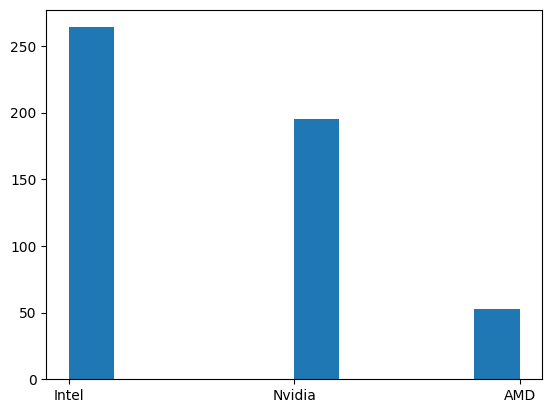

In [225]:
x = cheap_price["Gpu brand"]
y = cheap_price["Price"]

fig, ax = plt.subplots()
ax = plt.hist(x)


### Laptops de mas bajo precio $500 o menos

In [226]:
most_cheap_price.sort_values("Price", ascending=False)

,Company,TypeName,Ram,Price,Touchscreen,Ips,ppi,Cpu brand,HDD,SSD,Hybrid,Flash_Storage,Gpu brand,os
684,Dell,Notebook,8,499.925574,0,0,141.211998,Intel Core i5,0,256,0,0,Intel,Windows
214,HP,Notebook,8,499.296737,0,0,141.211998,Intel Core i5,1000,0,0,0,Intel,Windows
177,Toshiba,Notebook,8,498.667900,0,0,100.454670,Intel Core i5,0,128,0,0,Intel,Windows
788,Dell,Notebook,8,496.661909,0,0,141.211998,Intel Core i5,0,256,0,0,AMD,Windows
400,Acer,2 in 1 Convertible,8,496.158839,1,1,165.632118,Intel Core i7,0,256,0,0,Intel,Windows
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
765,Vero,Notebook,4,127.591068,0,0,157.350512,Other Intel Processor,0,0,0,32,Intel,Windows
30,Asus,Notebook,2,125.138603,0,0,111.935204,AMD Processor,0,0,0,32,AMD,Windows
280,Acer,Notebook,2,125.138603,0,0,100.454670,Other Intel Processor,0,16,0,0,Intel,Others/No OS/Linux
1088,Vero,Notebook,4,123.252091,0,0,165.632118,Other Intel Processor,0,0,0,32,Intel,Windows


In [227]:
most_cheap_price["Company"].value_counts()

Company
Lenovo      118
HP          110
Dell         91
Acer         79
Asus         62
Toshiba       8
Mediacom      7
Vero          4
Chuwi         3
Samsung       1
Fujitsu       1
Name: count, dtype: int64

In [228]:
most_cheap_price_RAM8capacity = most_cheap_price[
    (most_cheap_price["Ram"] == 8)]

most_cheap_price_RAM4capacity = most_cheap_price[
    (most_cheap_price["Ram"] == 4)]

most_cheap_price_RAM2capacity = most_cheap_price[
    (most_cheap_price["Ram"] == 2)]

In [229]:
most_cheap_price_RAM8capacity

,Company,TypeName,Ram,Price,Touchscreen,Ips,ppi,Cpu brand,HDD,SSD,Hybrid,Flash_Storage,Gpu brand,os
2,HP,Notebook,8,361.581390,0,0,141.211998,Intel Core i5,0,256,0,0,Intel,Others/No OS/Linux
9,Acer,Ultrabook,8,484.204644,0,1,157.350512,Intel Core i5,0,256,0,0,Intel,Windows
16,Dell,Notebook,8,468.483714,0,0,141.211998,Intel Core i7,0,256,0,0,AMD,Windows
18,Lenovo,Notebook,8,313.789763,0,0,141.211998,Intel Core i3,1000,0,0,0,Nvidia,Others/No OS/Linux
23,HP,Ultrabook,8,414.403715,0,0,141.211998,Intel Core i7,0,256,0,0,Intel,Windows
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1198,Dell,Notebook,8,294.930935,1,0,100.454670,Intel Core i3,1000,0,0,0,Intel,Windows
1213,Lenovo,Notebook,8,360.323716,0,1,141.211998,Intel Core i5,0,256,0,0,Intel,Others/No OS/Linux
1226,Asus,Ultrabook,8,458.422319,0,1,165.632118,Other Intel Processor,0,512,0,0,Intel,Windows
1240,Asus,Ultrabook,8,458.422319,0,1,165.632118,Other Intel Processor,0,512,0,0,Intel,Windows


In [230]:
most_cheap_price_RAM4capacity

,Company,TypeName,Ram,Price,Touchscreen,Ips,ppi,Cpu brand,HDD,SSD,Hybrid,Flash_Storage,Gpu brand,os
5,Acer,Notebook,4,251.534880,0,0,100.454670,AMD Processor,500,0,0,0,AMD,Windows
10,HP,Notebook,4,247.698973,0,0,100.454670,Intel Core i5,500,0,0,0,Intel,Others/No OS/Linux
11,HP,Notebook,4,216.942546,0,0,141.211998,Intel Core i3,500,0,0,0,Intel,Others/No OS/Linux
13,Dell,Notebook,4,313.726879,0,0,141.211998,Intel Core i3,0,256,0,0,AMD,Windows
21,HP,Notebook,4,162.239998,0,0,100.454670,AMD Processor,500,0,0,0,AMD,Others/No OS/Linux
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1253,Asus,Notebook,4,232.040927,0,0,100.454670,Other Intel Processor,500,0,0,0,Intel,Windows
1256,Acer,Notebook,4,181.733951,0,0,100.454670,Other Intel Processor,500,0,0,0,Intel,Others/No OS/Linux
1262,Asus,Notebook,4,452.964012,0,0,100.454670,Intel Core i7,500,0,0,0,Nvidia,Windows
1263,Lenovo,2 in 1 Convertible,4,401.198134,1,1,157.350512,Intel Core i7,0,128,0,0,Intel,Windows


In [231]:
most_cheap_price_RAM2capacity.sort_values("Price", ascending=False)

,Company,TypeName,Ram,Price,Touchscreen,Ips,ppi,Cpu brand,HDD,SSD,Hybrid,Flash_Storage,Gpu brand,os
88,Acer,Notebook,2,433.268831,0,0,141.211998,Intel Core i7,1000,0,0,0,Nvidia,Windows
1229,Dell,Notebook,2,238.329299,0,0,100.454670,Other Intel Processor,500,0,0,0,Intel,Windows
1243,Dell,Notebook,2,238.329299,0,0,100.454670,Other Intel Processor,500,0,0,0,Intel,Windows
1257,Dell,Notebook,2,238.329299,0,0,100.454670,Other Intel Processor,500,0,0,0,Intel,Windows
723,Acer,Notebook,2,207.516276,0,0,111.935204,Other Intel Processor,0,0,0,32,Intel,Others/No OS/Linux
396,Lenovo,Notebook,2,191.449486,0,0,135.094211,Other Intel Processor,0,0,0,32,Intel,Windows
335,HP,Notebook,2,175.445579,0,0,111.935204,Other Intel Processor,0,0,0,32,Intel,Windows
304,Asus,2 in 1 Convertible,2,172.930230,1,0,135.094211,Other Intel Processor,0,0,0,32,Intel,Windows
1136,HP,Notebook,2,156.580463,0,0,111.935204,Other Intel Processor,0,0,0,32,Intel,Windows
618,Lenovo,Notebook,2,156.580463,0,0,111.935204,Other Intel Processor,0,0,0,32,Intel,Windows


Text(0, 0.5, 'Price')

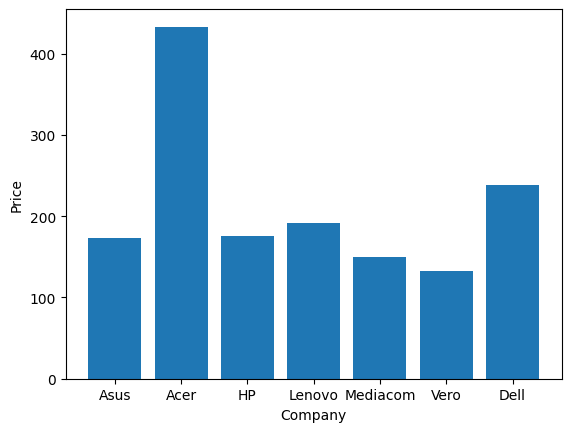

In [232]:
x = most_cheap_price_RAM2capacity["Company"]
y = most_cheap_price_RAM2capacity["Price"]

fig, ax = plt.subplots()

ax = plt.bar(x, y)
plt.title("")
plt.xlabel("Company")
plt.ylabel("Price")




<BarContainer object of 484 artists>

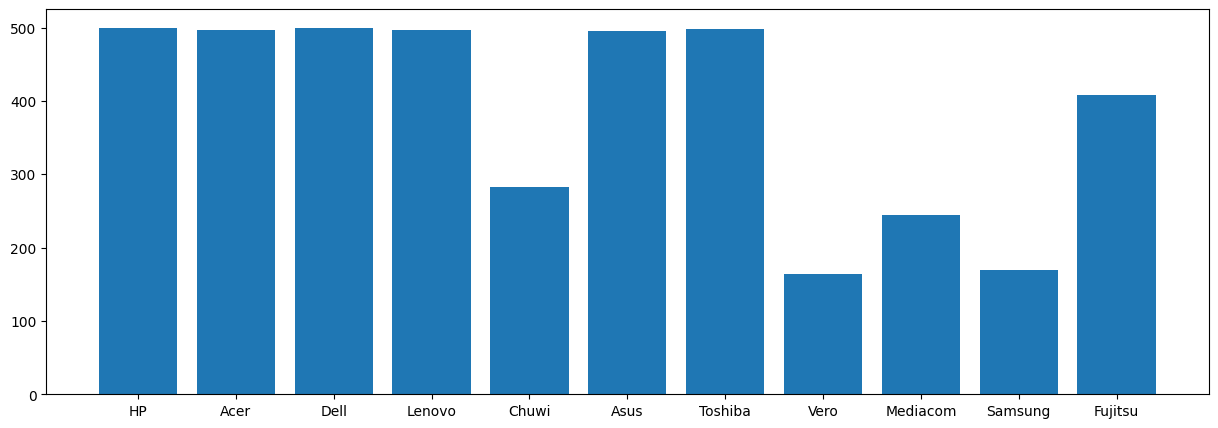

In [291]:
x = most_cheap_price["Company"]
y = most_cheap_price["Price"]

fig, ax = plt.subplots(
    figsize=(15,5)
)
ax.bar(x, y)

# Descripcion de variables
  - Company: Empresa que vende la laptop
  - TypeName: Tipo de laptop en cuestion
  - Ram: Cantidad de RAM en (GB)
  - Weight: Peso de la laptop en (Kg)
  - Price: Precio de la laption en (USD)
  - Ips:
  - ppi:
  - Cpu brand: Marca de la empresa de la Unidad central de procesamiento 
  - HDD: Unidad de disco duro
  - SSD: Unidad de estado solido
  - Flash_Storage:
  - Gpu brand: Marca de la empresa de la Unidad de procesamiento grafico
  - os: Sistema operativo